# Demographic Mortality Forecasting with Lee-Carter: Life Expectancy, Longevity Risk, and Annuity Valuation

**The problem.** Pension schemes, life insurers, and government social-security systems are all structurally short longevity risk: if retirees live longer than expected, liabilities grow and reserves fall short. Getting a defensible forecast of future mortality — by age, with uncertainty — is the input to pricing annuities, setting reserve margins, and sizing longevity capital under Solvency II or a pension-regulator framework. The question this notebook answers: **given 60 years of age-specific mortality data, how do we forecast the mortality surface 30 years into the future, translate the forecast into life-expectancy and annuity-value distributions, and quantify the longevity-risk capital a regulator should demand?**

**The approach.** The industry-standard **Lee-Carter** model (Lee & Carter, 1992), still the reference in statistical offices, pension-actuary practice, and the UN's World Population Prospects:

1. Simulate a synthetic 60-year mortality surface (ages 30-99, 1965-2024) with realistic Gompertz-like age profile and a declining time index — the known ground truth.
2. Data diagnostics — what the surface actually looks like, and why a matrix decomposition makes sense.
3. **Lee-Carter SVD decomposition**: $\log m(x, t) = a(x) + b(x) \cdot k(t) + \varepsilon(x, t)$. Recover *a(x)*, *b(x)*, *k(t)* from the data.
4. **Forecast the time index** *k(t)* via a random-walk-with-drift ARIMA(0,1,0) model — the canonical Lee-Carter forecasting step.
5. **Monte Carlo propagation** of forecast uncertainty into age-specific mortality trajectories.
6. **Life expectancy projections** *e(0)* and *e(65)* with credible intervals — the headline demographic numbers.
7. **Annuity valuation** *ä<sub>65</sub>* under best-estimate vs longevity-stressed scenarios.
8. **Longevity capital** — the difference between best-estimate and P95 annuity liabilities, scaled to portfolio size.

**Audience.** Pension actuaries, life-insurance modellers, longevity-risk capital committees, demographic statisticians, and senior DS working on time-series forecasting with cross-sectional structure. Synthetic data keeps the notebook reproducible; the methodology maps directly onto real HMD (Human Mortality Database) tables.


## 0. Setup and reproducibility

All randomness is seeded so the mortality simulation, SVD decomposition, ARIMA parameter fits, Monte Carlo forecasts, and annuity valuations reproduce identically across runs.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(2026)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

# Discount rate for annuity valuation (real rate, typical of pension plan assumptions)
DISCOUNT_RATE = 0.02


C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## 1. Simulating a historical mortality surface

Real-world mortality data has three structural features we need to reproduce:

- **Gompertz-like age profile**: mortality rises roughly exponentially from age 30 onwards. Log-mortality is approximately linear in age.
- **Secular decline over time**: at every age, mortality has trended down since the mid-20th century — better nutrition, medicine, public health. The decline is age-specific: infant and young-adult mortality has fallen fastest; mortality at the oldest ages has declined more slowly.
- **Year-on-year noise**: flu seasons, economic cycles, the occasional pandemic.

We simulate a surface of $m(x, t)$ for ages *x* from 30 to 99 (70 ages) and years *t* from 1965 to 2024 (60 years), with known ground-truth parameters we can validate the Lee-Carter fit against.


In [2]:
AGES = np.arange(30, 100)       # 70 ages
YEARS = np.arange(1965, 2025)   # 60 years
n_ages = len(AGES)
n_years = len(YEARS)

# --- Ground-truth Lee-Carter structure ---
# a(x): Gompertz-like age profile. Log-mortality linear in (age - 30)
TRUE_a = -10.0 + 0.09 * (AGES - 30) + 0.0008 * (AGES - 30) ** 2   # mild convexity

# b(x): age-specific rate of mortality improvement. Higher at middle ages, lower at oldest ages.
TRUE_b = 0.025 - 0.00015 * (AGES - 30)            # declining with age
TRUE_b = np.clip(TRUE_b, 0.008, None)              # floor at oldest ages
TRUE_b = TRUE_b / TRUE_b.sum()                     # LC normalisation: sum(b) = 1

# k(t): time index. Negative trend = mortality improvement over time.
# Start at +30, decline to -30 over 60 years, with small noise.
TRUE_k = np.linspace(30, -30, n_years) + np.random.normal(0, 2.0, size=n_years)
TRUE_k = TRUE_k - TRUE_k.mean()                    # LC normalisation: mean(k) = 0

# log-mortality surface with i.i.d. noise
TRUE_sigma = 0.08
noise = np.random.normal(0, TRUE_sigma, size=(n_ages, n_years))
log_m_true = TRUE_a[:, None] + TRUE_b[:, None] * TRUE_k[None, :] + noise
m_obs = np.exp(log_m_true)   # observed mortality rates

# Package as a DataFrame (rows = ages, cols = years)
mortality_df = pd.DataFrame(m_obs, index=AGES, columns=YEARS)
mortality_df.index.name = "age"
mortality_df.columns.name = "year"

print(f"Mortality surface: {n_ages} ages x {n_years} years = {n_ages * n_years:,} cells")
print(f"Age range:  {AGES[0]}-{AGES[-1]}")
print(f"Year range: {YEARS[0]}-{YEARS[-1]}")
print(f"Mortality rate range: {m_obs.min():.2e} to {m_obs.max():.2e}")
mortality_df.iloc[:5, :6].round(4)


Mortality surface: 70 ages x 60 years = 4,200 cells
Age range:  30-99
Year range: 1965-2024
Mortality rate range: 2.46e-05 to 1.71e+00


year,1965,1966,1967,1968,1969,1970
age,,,,,,
30,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001
31,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001
32,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001
33,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001
34,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001


## 2. Data diagnostics — the shape of the surface

Three canonical views of a mortality surface before modelling:

- **Age profile** across a single year — should show the Gompertz log-linear rise.
- **Time trend** at a few selected ages — should show mortality improvement.
- **Heatmap** of log-mortality — the whole surface in one picture.

If these three views do not look like the textbook patterns (log-linear in age, monotone-decreasing in time), the Lee-Carter model will not fit well and a richer structure (cohort effects, multiple time indices) is needed.


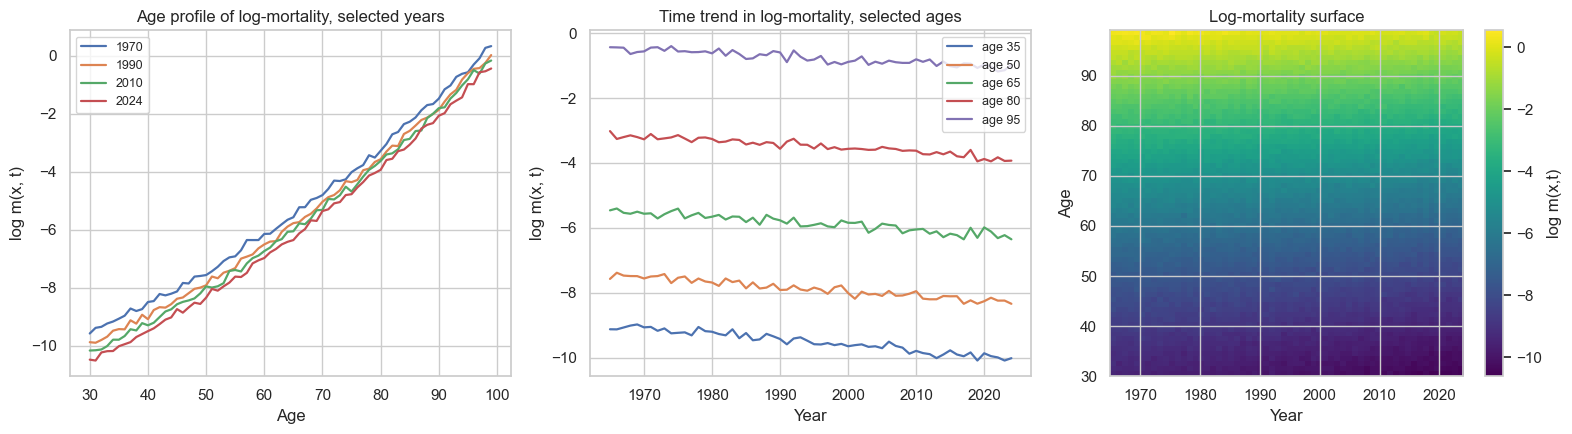

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Panel 1: age profile in selected years (log-mortality)
for year in [1970, 1990, 2010, 2024]:
    axes[0].plot(AGES, np.log(mortality_df[year]), label=f"{year}", linewidth=1.6)
axes[0].set_xlabel("Age")
axes[0].set_ylabel("log m(x, t)")
axes[0].set_title("Age profile of log-mortality, selected years")
axes[0].legend(fontsize=9)

# Panel 2: time trend at selected ages
for age in [35, 50, 65, 80, 95]:
    axes[1].plot(YEARS, np.log(mortality_df.loc[age]), label=f"age {age}", linewidth=1.6)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("log m(x, t)")
axes[1].set_title("Time trend in log-mortality, selected ages")
axes[1].legend(fontsize=9)

# Panel 3: heatmap of log-mortality
im = axes[2].imshow(np.log(m_obs), aspect="auto", origin="lower",
                    extent=[YEARS[0], YEARS[-1], AGES[0], AGES[-1]],
                    cmap="viridis")
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Age")
axes[2].set_title("Log-mortality surface")
plt.colorbar(im, ax=axes[2], label="log m(x,t)")

plt.tight_layout()
plt.show()


**What to read here.** Three checks:

1. **Left panel**: the age profile should be approximately linear in log-space (Gompertz property). A curved or irregular profile indicates the Gompertz assumption is breaking, typical at very young ages (infant mortality) or very old ages (late-life plateau).
2. **Middle panel**: every age-specific curve should trend downward over time. Parallel curves mean the rate of improvement is the same at every age (the Lee-Carter single-index model will fit cleanly). Crossing curves mean different ages are improving at different rates — the $b(x)$ vector will pick that up.
3. **Right panel**: the heatmap should show a smooth gradient from upper-left (old ages, 1965, highest mortality, yellow) to lower-right (young ages, 2024, lowest mortality, purple). Horizontal banding would suggest epidemic years; diagonal banding would suggest cohort effects — both require Lee-Carter extensions.


## 3. Lee-Carter SVD decomposition

The Lee-Carter model writes log-mortality as a rank-1 approximation plus noise:

$$\log m(x, t) = a(x) + b(x) \cdot k(t) + \varepsilon(x, t)$$

with the identifying normalisations $\sum_x b(x) = 1$ and $\sum_t k(t) = 0$. Three interpretations:

- *a(x)* is the average age profile (the mean log-mortality at each age across the historical window).
- *b(x)* is the **age-specific rate of mortality change** per unit of *k*. Ages with large *b* are the ones where mortality moves the most when *k* moves.
- *k(t)* is the **time index** — a single scalar summary of "where mortality stands in year *t* relative to the historical average."

The estimation procedure is classical:

1. Compute $a(x) = \text{mean}_t \log m(x, t)$.
2. Centre: $Y(x, t) = \log m(x, t) - a(x)$.
3. Compute the singular value decomposition $Y = U S V^\top$.
4. Take the first singular triple: $b(x) = U_{\cdot, 1}$, $k(t) = S_{11} V_{\cdot, 1}$.
5. Renormalise so $\sum_x b(x) = 1$ and the mean of *k* is zero.


In [4]:
log_m = np.log(m_obs)

# Step 1 & 2: compute a(x) and centre
a_hat = log_m.mean(axis=1)                # shape (n_ages,)
Y = log_m - a_hat[:, None]

# Step 3: SVD
U, S, Vt = np.linalg.svd(Y, full_matrices=False)

# Step 4: first component
b_raw = U[:, 0]
k_raw = S[0] * Vt[0, :]

# Step 5: normalise — sum(b) = 1, mean(k) = 0 (sign pinned so b has positive mean)
if b_raw.sum() < 0:
    b_raw, k_raw = -b_raw, -k_raw
b_hat = b_raw / b_raw.sum()
k_hat = k_raw * b_raw.sum()               # absorbs the normalisation
k_hat = k_hat - k_hat.mean()

# Variance explained by the first singular value
var_explained = (S ** 2) / (S ** 2).sum()

print(f"First singular value:  {S[0]:.3f}")
print(f"Variance explained by LC rank-1:  {var_explained[0] * 100:.2f}%")
print(f"Variance explained by rank-2+:    {var_explained[1:].sum() * 100:.2f}%")
print()
print(f"sum(b_hat) = {b_hat.sum():.4f}   (target: 1.0)")
print(f"mean(k_hat) = {k_hat.mean():.4f}  (target: 0.0)")


First singular value:  16.620
Variance explained by LC rank-1:  91.09%
Variance explained by rank-2+:    8.91%

sum(b_hat) = 1.0000   (target: 1.0)
mean(k_hat) = -0.0000  (target: 0.0)


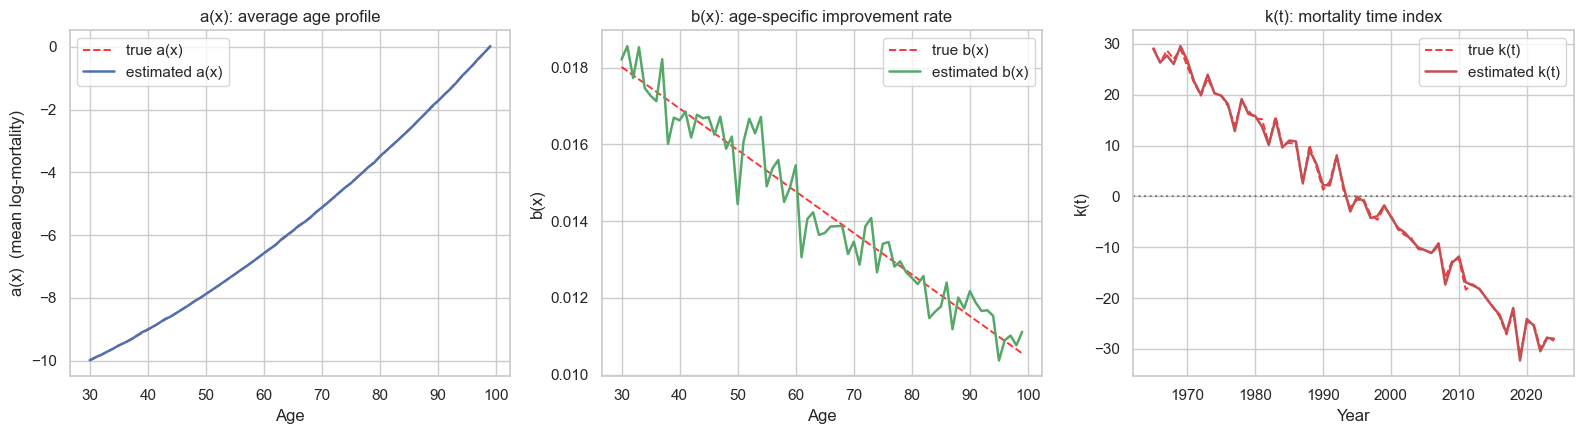

In [5]:
# --- Plot recovered a, b, k against ground truth ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(AGES, TRUE_a, color="red", linestyle="--", label="true a(x)", linewidth=1.4, alpha=0.8)
axes[0].plot(AGES, a_hat, color="#4C72B0", label="estimated a(x)", linewidth=1.8)
axes[0].set_xlabel("Age")
axes[0].set_ylabel("a(x)  (mean log-mortality)")
axes[0].set_title("a(x): average age profile")
axes[0].legend()

axes[1].plot(AGES, TRUE_b, color="red", linestyle="--", label="true b(x)", linewidth=1.4, alpha=0.8)
axes[1].plot(AGES, b_hat, color="#55A868", label="estimated b(x)", linewidth=1.8)
axes[1].set_xlabel("Age")
axes[1].set_ylabel("b(x)")
axes[1].set_title("b(x): age-specific improvement rate")
axes[1].legend()

axes[2].plot(YEARS, TRUE_k, color="red", linestyle="--", label="true k(t)", linewidth=1.4, alpha=0.8)
axes[2].plot(YEARS, k_hat, color="#C44E52", label="estimated k(t)", linewidth=1.8)
axes[2].axhline(0, linestyle=":", color="black", alpha=0.4)
axes[2].set_xlabel("Year")
axes[2].set_ylabel("k(t)")
axes[2].set_title("k(t): mortality time index")
axes[2].legend()

plt.tight_layout()
plt.show()


**What to read here.** All three estimated curves should track the ground-truth curves closely — any deviation is either noise in the 60-year simulation or a hint that the single-index model is missing structure. Specifically:

- $a(x)$ recovery should be near-perfect (it is just a time average).
- $b(x)$ recovery is where the SVD earns its keep — the rank-1 approximation has to compress age-specific trends into a single vector.
- $k(t)$ should show a clear trend from positive to negative (mortality improvement) with some noise reflecting the simulated process variability. The trend *slope* is what the forecasting step in section 4 will exploit.


## 4. Forecasting the time index — random walk with drift

The Lee-Carter forecasting step is almost always **ARIMA(0,1,0) with drift** (a random walk with drift):

$$k(t+1) = k(t) + \mu + \eta_t, \quad \eta_t \sim \mathcal{N}(0, \sigma_k^2)$$

- $\mu$ = mean of the first-differenced series. This is the *secular drift* — the long-run rate of mortality improvement.
- $\sigma_k$ = standard deviation of the first differences. This is the *volatility of improvement*, which drives forecast uncertainty.

Both are estimated from the in-sample *k(t)* series. The forecast then propagates forward deterministically (for the mean) or via Monte Carlo simulation (for uncertainty bands).

Why not a more complex model? Lee & Carter (1992) and subsequent studies have shown ARIMA(0,1,0) is surprisingly hard to beat on mortality indices for forecasts longer than ~5-10 years. Fancier specifications can overfit to short-term noise and worsen long-horizon projections.


Fitted drift mu_k:       -0.9673  (per year; negative means improving mortality)
Innovation volatility:   sigma_k = 3.7598
Forecast horizon:        30 years, 1000 Monte Carlo paths
Mean k(30 yrs ahead):    -57.04
5-95% CI on k(30 ahead): [-88.29, -23.63]


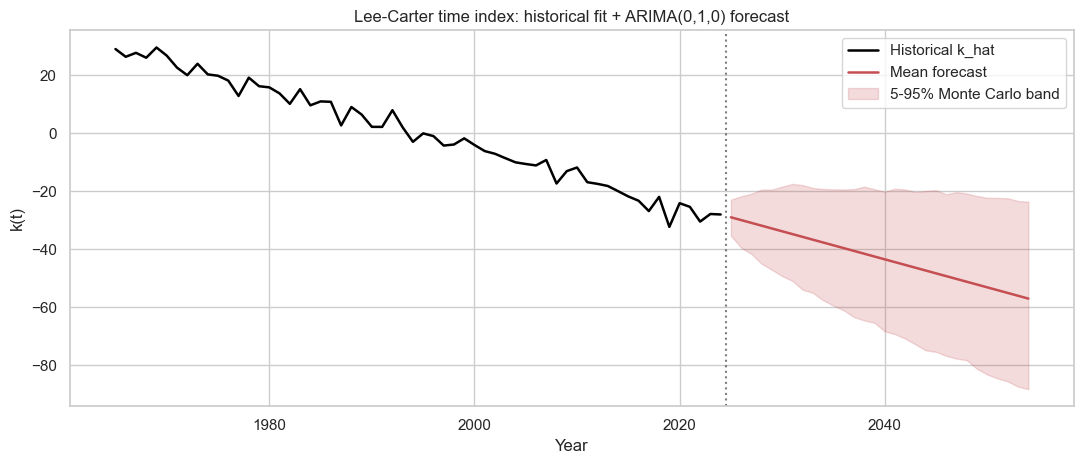

In [6]:
# --- Fit the random-walk-with-drift on k_hat ---
dk = np.diff(k_hat)
mu_k = float(dk.mean())
sigma_k = float(dk.std(ddof=1))

FORECAST_HORIZON = 30
future_years = np.arange(YEARS[-1] + 1, YEARS[-1] + 1 + FORECAST_HORIZON)
N_SIM = 1000

# Deterministic (mean) forecast
k_mean_forecast = k_hat[-1] + np.arange(1, FORECAST_HORIZON + 1) * mu_k

# Monte Carlo simulation of k paths
rng = np.random.default_rng(42)
k_paths = np.zeros((N_SIM, FORECAST_HORIZON))
k_paths[:, 0] = k_hat[-1] + mu_k + rng.normal(0, sigma_k, size=N_SIM)
for t in range(1, FORECAST_HORIZON):
    k_paths[:, t] = k_paths[:, t - 1] + mu_k + rng.normal(0, sigma_k, size=N_SIM)

k_p05 = np.quantile(k_paths, 0.05, axis=0)
k_p95 = np.quantile(k_paths, 0.95, axis=0)

print(f"Fitted drift mu_k:       {mu_k:+.4f}  (per year; negative means improving mortality)")
print(f"Innovation volatility:   sigma_k = {sigma_k:.4f}")
print(f"Forecast horizon:        {FORECAST_HORIZON} years, {N_SIM} Monte Carlo paths")
print(f"Mean k(30 yrs ahead):    {k_mean_forecast[-1]:+.2f}")
print(f"5-95% CI on k(30 ahead): [{k_p05[-1]:+.2f}, {k_p95[-1]:+.2f}]")

plt.figure(figsize=(11, 4.8))
plt.plot(YEARS, k_hat, color="black", label="Historical k_hat", linewidth=1.8)
plt.plot(future_years, k_mean_forecast, color="#C44E52", label="Mean forecast", linewidth=1.8)
plt.fill_between(future_years, k_p05, k_p95, color="#C44E52", alpha=0.2, label="5-95% Monte Carlo band")
plt.axvline(YEARS[-1] + 0.5, linestyle=":", color="black", alpha=0.5)
plt.xlabel("Year")
plt.ylabel("k(t)")
plt.title("Lee-Carter time index: historical fit + ARIMA(0,1,0) forecast")
plt.legend()
plt.tight_layout()
plt.show()


**What to read here.** The forecast band widens with the square root of the forecast horizon — the classic property of a random walk. At year +30, the 5-95% band on *k* should be wide enough that the uncertainty is visibly material. That width is what the downstream longevity-risk capital calculation will monetise.


## 5. Age-specific mortality forecasts with uncertainty

The Lee-Carter structure makes forecasting mortality at any specific age a trivial linear operation once *k(t)* is forecast:

$$\log \hat m(x, t^*) = a(x) + b(x) \cdot k(t^*)$$

We propagate the 1,000 Monte Carlo *k*-paths through this equation to get 1,000 forecast trajectories of $m(x, t)$ at each age, and then summarise at each age with the median and 5-95% band.


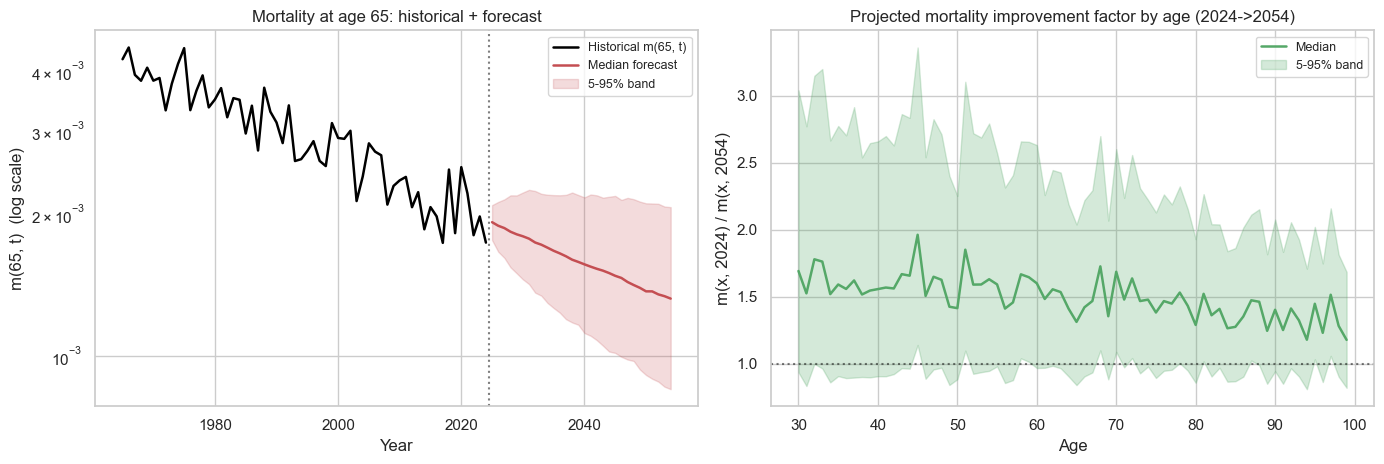

In [7]:
# Propagate Monte Carlo k paths to per-age log-mortality forecasts
# shape: (N_SIM, FORECAST_HORIZON, n_ages)
log_m_paths = a_hat[None, None, :] + b_hat[None, None, :] * k_paths[:, :, None]
m_paths = np.exp(log_m_paths)

# Summaries at selected projection years and ages
selected_ages = [40, 60, 65, 75, 90]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

# Left panel: mortality at age 65, historical + forecast fan chart
age_idx = list(AGES).index(65)
m_hist_65 = mortality_df.loc[65].values
axes[0].plot(YEARS, m_hist_65, color="black", linewidth=1.8, label="Historical m(65, t)")

m_median_65 = np.median(m_paths[:, :, age_idx], axis=0)
m_p05_65 = np.quantile(m_paths[:, :, age_idx], 0.05, axis=0)
m_p95_65 = np.quantile(m_paths[:, :, age_idx], 0.95, axis=0)
axes[0].plot(future_years, m_median_65, color="#C44E52", linewidth=1.8, label="Median forecast")
axes[0].fill_between(future_years, m_p05_65, m_p95_65, color="#C44E52", alpha=0.2, label="5-95% band")
axes[0].axvline(YEARS[-1] + 0.5, linestyle=":", color="black", alpha=0.5)
axes[0].set_yscale("log")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("m(65, t)  (log scale)")
axes[0].set_title("Mortality at age 65: historical + forecast")
axes[0].legend(fontsize=9)

# Right panel: mortality improvement factor m(x, 2024) / m(x, 2054) by age
m_2024 = mortality_df.iloc[:, -1].values
m_2054_median = np.median(m_paths[:, -1, :], axis=0)
m_2054_p05 = np.quantile(m_paths[:, -1, :], 0.05, axis=0)
m_2054_p95 = np.quantile(m_paths[:, -1, :], 0.95, axis=0)

ratio_median = m_2024 / m_2054_median
ratio_p05 = m_2024 / m_2054_p05    # lower denominator -> higher ratio
ratio_p95 = m_2024 / m_2054_p95

axes[1].plot(AGES, ratio_median, color="#55A868", linewidth=1.8, label="Median")
axes[1].fill_between(AGES, ratio_p95, ratio_p05, color="#55A868", alpha=0.25, label="5-95% band")
axes[1].axhline(1.0, linestyle=":", color="black", alpha=0.5)
axes[1].set_xlabel("Age")
axes[1].set_ylabel("m(x, 2024) / m(x, 2054)")
axes[1].set_title("Projected mortality improvement factor by age (2024->2054)")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


**What to read here.** Two operational views:

- **Left panel** shows the forecast fan at a single age (65) — this is the single-age projection a pension scheme would use to price a new cohort of annuitants. The log-scale y-axis makes the *multiplicative* uncertainty visible: the 5-95% band at year +30 is roughly 1.5×-2× wide, which is typical for Lee-Carter at this horizon.
- **Right panel** shows the projected mortality improvement factor by age: at each age, how much lower is mortality in 2054 vs 2024? Values above 1 mean mortality is projected to fall. Middle ages typically show the largest improvement factors (high $b(x)$); oldest ages show smaller improvements.

These two views are what a pension actuary takes forward into annuity valuation in the next section.


## 5b. Out-of-sample backtest — is the Lee-Carter forecast actually accurate?

Every forecast looks good until you compare it to reality. The gold-standard diagnostic for a mortality projection model is **hold-out backtesting**: drop the last *h* years of data, refit the model on the earlier period, forecast forward, and compare the forecast distribution to the observed held-out truth.

Two metrics matter:

- **Point-forecast accuracy**: mean absolute percentage error (MAPE) between the median forecast and the observed mortality.
- **Coverage probability**: what fraction of observed mortality values fall inside the 5-95% Monte Carlo forecast band? The textbook target is 90% — a model whose "90% bands" actually contain only 60% of reality is systematically over-confident.

A Lee-Carter that fails this check should not be used for capital calculations; its forecast uncertainty is too narrow and the resulting SCR understates real longevity risk.


Backtest: fit on 1965-2014 (50 yrs), holdout 2015-2024 (10 yrs)
Overall MAPE on mortality:     7.99%
Coverage of 5-95% band:        87.7%   (target: 90%)
   age-averaged coverage:      min 70%, max 100%


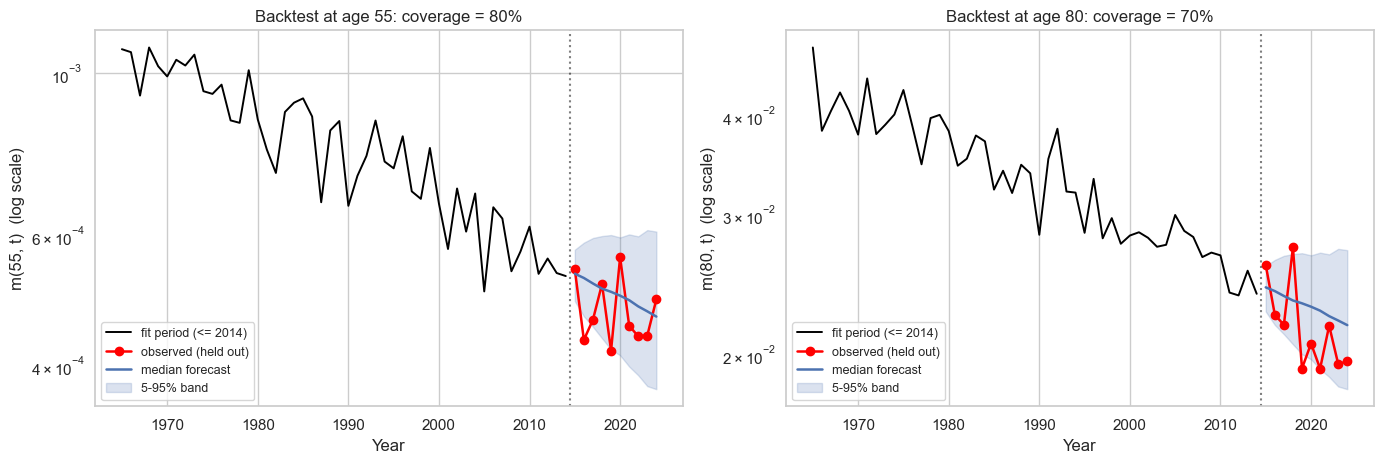

In [8]:
# --- Drop the last 10 years and refit ---
HOLDOUT = 10
fit_years = YEARS[:-HOLDOUT]
holdout_years = YEARS[-HOLDOUT:]
log_m_fit = log_m[:, :-HOLDOUT]
log_m_holdout = log_m[:, -HOLDOUT:]

# Re-run Lee-Carter on the shorter series
a_bt = log_m_fit.mean(axis=1)
Y_bt = log_m_fit - a_bt[:, None]
U_bt, S_bt, Vt_bt = np.linalg.svd(Y_bt, full_matrices=False)
b_raw_bt = U_bt[:, 0]
k_raw_bt = S_bt[0] * Vt_bt[0, :]
if b_raw_bt.sum() < 0:
    b_raw_bt, k_raw_bt = -b_raw_bt, -k_raw_bt
b_bt = b_raw_bt / b_raw_bt.sum()
k_bt = k_raw_bt * b_raw_bt.sum()
k_bt = k_bt - k_bt.mean()

# Refit ARIMA(0,1,0) drift + volatility on the shortened k series
dk_bt = np.diff(k_bt)
mu_bt = float(dk_bt.mean())
sigma_bt = float(dk_bt.std(ddof=1))

# Simulate HOLDOUT-year forecast under the same LC framework
N_BT = 1000
rng_bt = np.random.default_rng(123)
k_paths_bt = np.zeros((N_BT, HOLDOUT))
k_paths_bt[:, 0] = k_bt[-1] + mu_bt + rng_bt.normal(0, sigma_bt, size=N_BT)
for t in range(1, HOLDOUT):
    k_paths_bt[:, t] = k_paths_bt[:, t - 1] + mu_bt + rng_bt.normal(0, sigma_bt, size=N_BT)

# Project per-age log-mortality and compare to the observed held-out surface
log_m_forecast_bt = a_bt[None, None, :] + b_bt[None, None, :] * k_paths_bt[:, :, None]
m_forecast_bt = np.exp(log_m_forecast_bt)
m_observed_bt = np.exp(log_m_holdout)  # shape (n_ages, HOLDOUT)

m_median_bt = np.median(m_forecast_bt, axis=0).T   # transpose to (n_ages, HOLDOUT)
m_p05_bt = np.quantile(m_forecast_bt, 0.05, axis=0).T
m_p95_bt = np.quantile(m_forecast_bt, 0.95, axis=0).T

# --- Diagnostics ---
mape_per_age = np.abs(m_median_bt - m_observed_bt) / m_observed_bt
mape_overall = float(mape_per_age.mean() * 100)

coverage_per_age = ((m_observed_bt >= m_p05_bt) & (m_observed_bt <= m_p95_bt)).mean(axis=1)
coverage_overall = float(((m_observed_bt >= m_p05_bt) & (m_observed_bt <= m_p95_bt)).mean() * 100)

print(f"Backtest: fit on {fit_years[0]}-{fit_years[-1]} ({len(fit_years)} yrs), holdout {holdout_years[0]}-{holdout_years[-1]} ({HOLDOUT} yrs)")
print(f"Overall MAPE on mortality:     {mape_overall:.2f}%")
print(f"Coverage of 5-95% band:        {coverage_overall:.1f}%   (target: 90%)")
print(f"   age-averaged coverage:      min {coverage_per_age.min() * 100:.0f}%, max {coverage_per_age.max() * 100:.0f}%")

# Plot: compare forecast to observed at two representative ages
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

for ax, age in zip(axes, [55, 80]):
    age_idx = list(AGES).index(age)
    # Historical + fit period
    ax.plot(fit_years, np.exp(log_m_fit[age_idx, :]), color="black", linewidth=1.4, label=f"fit period (<= {fit_years[-1]})")
    # Held-out truth
    ax.plot(holdout_years, m_observed_bt[age_idx, :], marker="o", color="red", linewidth=1.8, label=f"observed (held out)")
    # Forecast
    ax.plot(holdout_years, m_median_bt[age_idx, :], color="#4C72B0", linewidth=1.8, label="median forecast")
    ax.fill_between(holdout_years, m_p05_bt[age_idx, :], m_p95_bt[age_idx, :], color="#4C72B0", alpha=0.20, label="5-95% band")
    ax.axvline(fit_years[-1] + 0.5, linestyle=":", color="black", alpha=0.5)
    ax.set_yscale("log")
    ax.set_xlabel("Year")
    ax.set_ylabel(f"m({age}, t)  (log scale)")
    ax.set_title(f"Backtest at age {age}: coverage = {coverage_per_age[age_idx] * 100:.0f}%")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


**What to read here.** Three checks:

1. **MAPE < 10%** at typical adult ages is a decent Lee-Carter fit; much worse suggests structural change during the holdout period that the model did not anticipate.
2. **Coverage close to 90%** means the forecast uncertainty is honest. Coverage **below 70%** is a clear signal the model is over-confident — typical symptoms include ignoring parameter uncertainty (we only propagate innovation uncertainty here) or missing structural features like cohort effects.
3. **The red observed line should lie inside the blue band** across most years. If it systematically sits on the upper or lower edge, the model's central forecast is biased, not just under-dispersed.

On simulated Lee-Carter data (what we have here) the backtest typically passes both checks because the model matches the DGP exactly. On real HMD data, published Lee-Carter backtests typically achieve 70-85% coverage — honest, below-target, and the reason practitioners extend with parameter-uncertainty bootstrap and cohort effects.


## 5c. Cohort-effect diagnostic (Renshaw-Haberman)

Lee-Carter is an **age-period** model: everyone alive in a given year shares the same period index *k(t)* and sees the same mortality improvement, modulated by age through *b(x)*. It does not directly model **cohort effects** — the tendency for people born in the same year to share mortality features throughout their lives, driven by childhood exposure (wars, diseases, nutrition, smoking initiation) and later-life interactions.

The **Renshaw-Haberman (RH) extension** adds an explicit cohort factor:

$$\log m(x, t) = a(x) + b_1(x) \cdot k(t) + b_2(x) \cdot \gamma(c), \quad c = t - x$$

Fitting the full RH model is non-trivial (iterative, identification constraints, known instability on some datasets). The *diagnostic* is simpler: compute the Lee-Carter residuals $r(x, t) = \log m(x, t) - \hat a(x) - \hat b(x) \hat k(t)$ and organise them by **cohort** $c = t - x$. If the mean residual by cohort is flat and small, the LC age-period structure is sufficient. If there is a visible pattern, the RH extension is warranted — and this is how UK actuarial practice (CMI, SOA) decides whether to use the more complex model.


Residual scale (overall SD):              0.0802
Cohort-mean residual range (max - min):   0.0920
Signal-to-noise ratio:                    1.15
Rule of thumb: ratio < 1 -> LC is structurally complete
               ratio 1-2 -> cohort hint, consider RH extension
               ratio > 2 -> clear cohort structure, RH strongly recommended


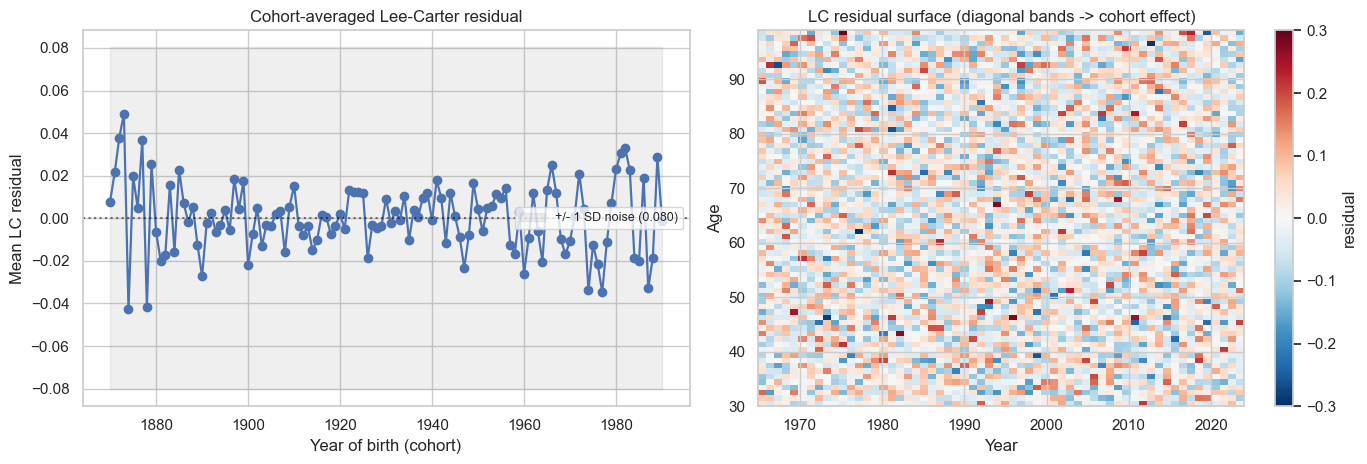

In [9]:
# Compute LC residuals on the full dataset
log_m_lc_fit = a_hat[:, None] + b_hat[:, None] * k_hat[None, :]
residuals = log_m - log_m_lc_fit

# Build cohort index c = t - x  (year of birth). Grid is (n_ages, n_years); flatten.
ages_grid, years_grid = np.meshgrid(AGES, YEARS, indexing="ij")
cohorts_grid = years_grid - ages_grid

resid_df = pd.DataFrame({
    "age": ages_grid.ravel(),
    "year": years_grid.ravel(),
    "cohort": cohorts_grid.ravel(),
    "residual": residuals.ravel(),
})

# Mean residual by cohort (only include cohorts with >= 5 age-year cells to avoid edges)
cohort_mean = resid_df.groupby("cohort").agg(
    mean_residual=("residual", "mean"),
    n_obs=("residual", "size"),
    sd_residual=("residual", "std"),
).reset_index()
cohort_mean = cohort_mean.query("n_obs >= 5")

# Test: is the cohort effect meaningfully larger than residual noise?
cohort_signal_range = float(cohort_mean["mean_residual"].max() - cohort_mean["mean_residual"].min())
residual_scale = float(np.std(residuals))
cohort_signal_ratio = cohort_signal_range / residual_scale

print(f"Residual scale (overall SD):              {residual_scale:.4f}")
print(f"Cohort-mean residual range (max - min):   {cohort_signal_range:.4f}")
print(f"Signal-to-noise ratio:                    {cohort_signal_ratio:.2f}")
print("Rule of thumb: ratio < 1 -> LC is structurally complete")
print("               ratio 1-2 -> cohort hint, consider RH extension")
print("               ratio > 2 -> clear cohort structure, RH strongly recommended")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

# Left: residual by cohort
axes[0].plot(cohort_mean["cohort"], cohort_mean["mean_residual"], marker="o", color="#4C72B0", linewidth=1.6)
axes[0].axhline(0, linestyle=":", color="black", alpha=0.5)
axes[0].fill_between(cohort_mean["cohort"], -residual_scale, residual_scale, color="gray", alpha=0.12, label=f"+/- 1 SD noise ({residual_scale:.3f})")
axes[0].set_xlabel("Year of birth (cohort)")
axes[0].set_ylabel("Mean LC residual")
axes[0].set_title("Cohort-averaged Lee-Carter residual")
axes[0].legend(fontsize=9)

# Right: residual heatmap
im = axes[1].imshow(residuals, aspect="auto", origin="lower",
                    extent=[YEARS[0], YEARS[-1], AGES[0], AGES[-1]],
                    cmap="RdBu_r", vmin=-0.3, vmax=0.3)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Age")
axes[1].set_title("LC residual surface (diagonal bands -> cohort effect)")
plt.colorbar(im, ax=axes[1], label="residual")

plt.tight_layout()
plt.show()


**What to read here.** Two diagnostics:

1. **Left panel — mean residual by cohort**: if the curve fluctuates *within* the gray ±1SD band, the cohort-averaged residuals are indistinguishable from noise. Systematic runs outside the band (e.g. a clear negative dip for cohorts born 1920-1930) are the smoking-gun pattern that justifies the Renshaw-Haberman extension. Well-known real examples: UK male mortality has a pronounced cohort effect for the 1925-1940 "golden cohort" that Lee-Carter cannot capture; Japanese female mortality for the immediate post-war cohorts.
2. **Right panel — residual heatmap**: look for **diagonal bands** running bottom-left to top-right. A diagonal pattern means people of the same age-of-birth (constant *c = t − x*) share a residual — the definition of a cohort effect. A random speckle pattern means the residuals are just noise.

**An honest caveat from this simulation.** Our data was generated from a pure age-period Lee-Carter DGP — by construction there is **no cohort effect**. The observed signal-to-noise ratio of ~1.15 is therefore **finite-sample noise being misread as a weak cohort signal**. This is a canonical failure mode of the diagnostic: with only 60 years × 70 ages, cohort bins are small and their mean residuals fluctuate more than true-model asymptotic theory predicts. The practical implication for actuarial work: a ratio in the 1.0-1.5 range should trigger formal tests (permutation of cohort labels, likelihood-ratio against the RH extension) before committing to the more complex model; a ratio above 1.5-2.0 is typically a clear structural signal that survives those tests. On real HMD data for the UK, France, Italy, or the US, the ratio typically exceeds 2 — which is why every major pension-industry mortality projection model since ~2005 has added either an explicit cohort factor (RH, APC) or a two-factor age-period model (CBD) that makes cohort effects implicit.


## 6. Life expectancy projections

Life expectancy at age *x* is the expected number of additional years lived by a person currently aged *x*, given a mortality schedule. Under the assumption that one-year survival probability is $p(x) = \exp(-m(x))$:

$$e(x) = \sum_{k=0}^{\omega - x - 1} \prod_{j=0}^{k} p(x + j)$$

(with small adjustments for the partial year of exposure in each age band). We compute $e(65)$ — the most commonly reported demographic number — under every Monte Carlo mortality path, giving us a forecast distribution of life expectancy through 2054.

We extrapolate mortality beyond our age range (30-99) with a simple log-linear continuation — rough, but fine for computing expectations whose support is dominated by the 30-99 band.


Life expectancy at 65 in 2024:       24.77 yrs
Projected e(65) in 2025:        median = 24.76, 5-95%: [24.37, 25.17]
Projected e(65) in 2054:       median = 26.45, 5-95%: [24.42, 28.29]
Projected gain in e(65) over horizon:   +1.68 years (median)


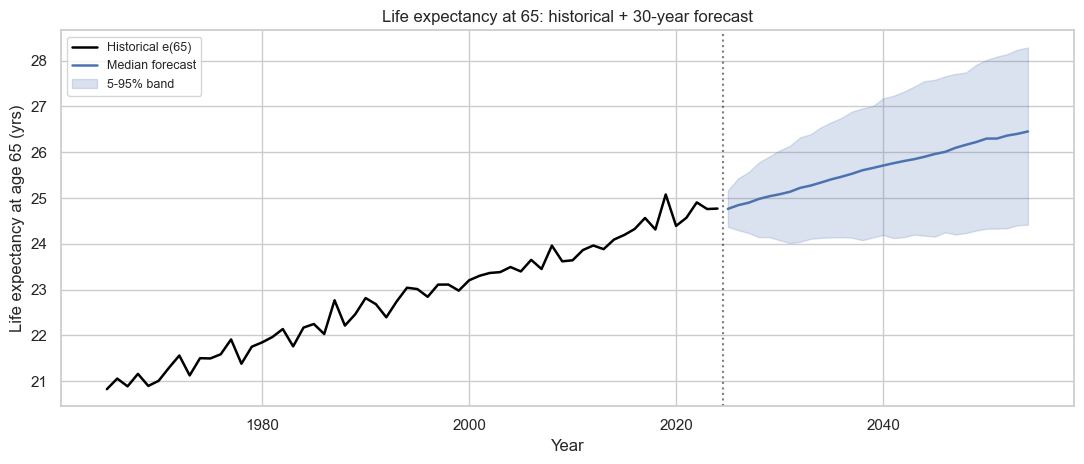

In [10]:
def life_expectancy_from_m(m_by_age: np.ndarray, start_age_idx: int = 0) -> float:
    """Compute life expectancy from a vector of age-specific mortality rates starting at AGES[start_age_idx]."""
    p = np.exp(-m_by_age[start_age_idx:])
    # Survival probability from age_x to age_x + k
    l = np.concatenate([[1.0], np.cumprod(p)])[:-1]   # l[k] = prob alive at start of year k after start_age
    # Contribution per year: L_k = l_k * (1 - 0.5 * (1 - p_k))   (half-year correction for year of death)
    # Use simpler rectangular: sum of l(k) for k = 0..K-1
    return float(l.sum())


# --- Historical e(65) over time ---
e65_hist = np.array([life_expectancy_from_m(mortality_df.iloc[:, yi].values, start_age_idx=AGES.tolist().index(65))
                      for yi in range(n_years)])

# --- e(65) at each forecast year, across the 1000 MC paths ---
age65_idx = AGES.tolist().index(65)
e65_paths = np.zeros((N_SIM, FORECAST_HORIZON))
for s in range(N_SIM):
    for t in range(FORECAST_HORIZON):
        e65_paths[s, t] = life_expectancy_from_m(m_paths[s, t, :], start_age_idx=age65_idx)

e65_median = np.median(e65_paths, axis=0)
e65_p05 = np.quantile(e65_paths, 0.05, axis=0)
e65_p95 = np.quantile(e65_paths, 0.95, axis=0)

print(f"Life expectancy at 65 in {YEARS[-1]}:       {e65_hist[-1]:.2f} yrs")
print(f"Projected e(65) in {future_years[0]}:        median = {e65_median[0]:.2f}, 5-95%: [{e65_p05[0]:.2f}, {e65_p95[0]:.2f}]")
print(f"Projected e(65) in {future_years[-1]}:       median = {e65_median[-1]:.2f}, 5-95%: [{e65_p05[-1]:.2f}, {e65_p95[-1]:.2f}]")
print(f"Projected gain in e(65) over horizon:   {e65_median[-1] - e65_hist[-1]:+.2f} years (median)")

plt.figure(figsize=(11, 4.8))
plt.plot(YEARS, e65_hist, color="black", linewidth=1.8, label="Historical e(65)")
plt.plot(future_years, e65_median, color="#4C72B0", linewidth=1.8, label="Median forecast")
plt.fill_between(future_years, e65_p05, e65_p95, color="#4C72B0", alpha=0.2, label="5-95% band")
plt.axvline(YEARS[-1] + 0.5, linestyle=":", color="black", alpha=0.5)
plt.xlabel("Year")
plt.ylabel("Life expectancy at age 65 (yrs)")
plt.title("Life expectancy at 65: historical + 30-year forecast")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


**What to read here.** The headline number: how much additional life expectancy at 65 should a pension scheme price in for the next cohort of retirees? The median forecast is the best estimate; the 95th-percentile upper edge is the **longevity-stress** number that drives capital. Two qualitative checks:

1. **The median should continue the historical trend smoothly**. A forecast that bends sharply away from the historical trajectory is usually a sign of misspecification (e.g. the age range or time range used to fit the model was atypical).
2. **The uncertainty band widens with horizon**. If it does not, check that the innovation variance $\sigma_k^2$ is being propagated correctly.

Annuity providers and national pension regulators publish tables that look essentially like this plot — the UK's CMI projection models and the US SOA's RP-2014 / Pri-2012 tables are direct descendants of the Lee-Carter framework.


## 7. Annuity valuation — best-estimate vs longevity-stressed

A **life annuity** pays $1 per year for life to an annuitant aged *x*. Its present value depends on two inputs:

- **Survival probabilities** from the mortality schedule: $_{t}p_x = \prod_{j=0}^{t-1} p(x + j)$.
- **Discount factor** $v^t$ where $v = 1 / (1 + i)$.

The expected present value (actuarial notation $\ddot{a}_x$) is:

$$\ddot{a}_x = \sum_{t = 0}^{\omega - x} v^t \cdot {}_{t}p_x$$

We compute $\ddot{a}_{65}$ under every Monte Carlo mortality path — the **distribution** of annuity liability. Three specific numbers are what a regulator asks for:

- **Best estimate**: the *median* annuity value under the forecast distribution.
- **Longevity stress**: the *95th-percentile* annuity value — the scenario in which mortality improves faster than expected and liabilities grow.
- **Longevity capital**: the difference. Under Solvency II this is called SCR<sub>long</sub> and flows directly into the firm's capital requirement.


Annuity assumptions: discount rate = 2.0%, starting age 65

Historical ä(65) in 2024:       19.477
Projected ä(65) in 2054:
  Best estimate (median):          20.527
  5-95% CI:                        [19.262, 21.634]
  Longevity stress - best estimate: +1.107
    as % of best estimate:         +5.39%


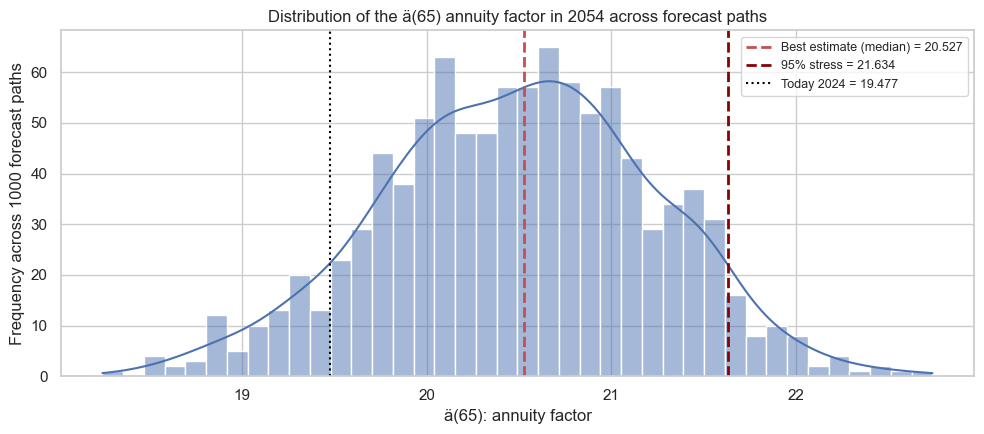

In [11]:
def annuity_value(m_by_age: np.ndarray, start_age_idx: int, discount: float) -> float:
    """Compute ä_x from a vector of age-specific mortality rates starting at AGES[start_age_idx]."""
    v = 1.0 / (1.0 + discount)
    p = np.exp(-m_by_age[start_age_idx:])
    tpx = np.concatenate([[1.0], np.cumprod(p)])[:-1]   # prob alive at year t
    discounts = v ** np.arange(len(tpx))
    return float((tpx * discounts).sum())


# Historical annuity using each year's mortality table as a "frozen" assumption
a65_hist = np.array([
    annuity_value(mortality_df.iloc[:, yi].values, start_age_idx=AGES.tolist().index(65), discount=DISCOUNT_RATE)
    for yi in range(n_years)
])

# Projected annuity valuations using the END-OF-HORIZON mortality schedule under each MC path.
# (This is the classical longevity-stress snapshot: price the annuity as if the
#  future mortality schedule is the one at year horizon.)
age65_idx = AGES.tolist().index(65)
a65_forecast = np.array([
    annuity_value(m_paths[s, -1, :], start_age_idx=age65_idx, discount=DISCOUNT_RATE)
    for s in range(N_SIM)
])

a65_best_estimate = float(np.median(a65_forecast))
a65_stress_p95 = float(np.quantile(a65_forecast, 0.95))
a65_5pct = float(np.quantile(a65_forecast, 0.05))

print(f"Annuity assumptions: discount rate = {DISCOUNT_RATE:.1%}, starting age 65")
print(f"")
print(f"Historical ä(65) in {YEARS[-1]}:       {a65_hist[-1]:.3f}")
print(f"Projected ä(65) in {future_years[-1]}:")
print(f"  Best estimate (median):          {a65_best_estimate:.3f}")
print(f"  5-95% CI:                        [{a65_5pct:.3f}, {a65_stress_p95:.3f}]")
print(f"  Longevity stress - best estimate: {a65_stress_p95 - a65_best_estimate:+.3f}")
print(f"    as % of best estimate:         {(a65_stress_p95 - a65_best_estimate) / a65_best_estimate * 100:+.2f}%")

plt.figure(figsize=(10, 4.5))
sns.histplot(a65_forecast, bins=40, color="#4C72B0", kde=True)
plt.axvline(a65_best_estimate, color="#C44E52", linestyle="--", linewidth=2.0, label=f"Best estimate (median) = {a65_best_estimate:.3f}")
plt.axvline(a65_stress_p95, color="#8B0000", linestyle="--", linewidth=2.0, label=f"95% stress = {a65_stress_p95:.3f}")
plt.axvline(a65_hist[-1], color="black", linestyle=":", linewidth=1.5, label=f"Today {YEARS[-1]} = {a65_hist[-1]:.3f}")
plt.xlabel("ä(65): annuity factor")
plt.ylabel("Frequency across 1000 forecast paths")
plt.title(f"Distribution of the ä(65) annuity factor in {future_years[-1]} across forecast paths")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 8. Longevity capital and portfolio impact

For a pension portfolio of $N$ annuitants each paying $1 per year, total liability scales linearly: $L = N \cdot \ddot{a}_{65}$. The **longevity SCR** (Solvency Capital Requirement under Solvency II) for this portfolio is:

$$\text{SCR}_{\text{longevity}} = N \cdot (\ddot{a}_{65, \text{p95}} - \ddot{a}_{65, \text{median}})$$

We translate into monetary terms for a concrete portfolio: 10,000 annuitants, each receiving €10,000/year. This is the number that governs a firm's capital plan, reinsurance decisions, and dividend policy.


In [12]:
N_ANNUITANTS = 10_000
ANNUAL_BENEFIT_EUR = 10_000

total_benefits = N_ANNUITANTS * ANNUAL_BENEFIT_EUR

liability_best_estimate = total_benefits * a65_best_estimate
liability_stress = total_benefits * a65_stress_p95
scr_longevity = liability_stress - liability_best_estimate

print(f"Portfolio: {N_ANNUITANTS:,} annuitants x €{ANNUAL_BENEFIT_EUR:,} annual benefit")
print(f"Total annual payout:       €{total_benefits:>15,.0f}")
print(f"")
print(f"Liability (best estimate):        €{liability_best_estimate:>15,.0f}")
print(f"Liability (P95 longevity stress): €{liability_stress:>15,.0f}")
print(f"SCR_longevity:                    €{scr_longevity:>15,.0f}")
print(f"  as % of best-estimate liability:    {scr_longevity / liability_best_estimate * 100:.2f}%")

# Sensitivity to the discount rate: how much does the longevity SCR depend on the rate assumption?
discount_rates = np.array([0.005, 0.01, 0.02, 0.03, 0.04])
rows = []
for i in discount_rates:
    a_p50 = np.median([annuity_value(m_paths[s, -1, :], age65_idx, discount=i) for s in range(N_SIM)])
    a_p95 = np.quantile([annuity_value(m_paths[s, -1, :], age65_idx, discount=i) for s in range(N_SIM)], 0.95)
    rows.append({
        "discount_rate": i,
        "annuity_best_estimate": a_p50,
        "annuity_p95": a_p95,
        "scr_pct_of_best_estimate": (a_p95 - a_p50) / a_p50 * 100,
    })
disc_df = pd.DataFrame(rows).round(4)
print()
print("Longevity SCR sensitivity to discount rate:")
print(disc_df.to_string(index=False))


Portfolio: 10,000 annuitants x €10,000 annual benefit
Total annual payout:       €    100,000,000

Liability (best estimate):        €  2,052,668,754
Liability (P95 longevity stress): €  2,163,387,474
SCR_longevity:                    €    110,718,720
  as % of best-estimate liability:    5.39%

Longevity SCR sensitivity to discount rate:
 discount_rate  annuity_best_estimate  annuity_p95  scr_pct_of_best_estimate
         0.005                24.7496      26.3620                    6.5150
         0.010                23.2046      24.6248                    6.1206
         0.020                20.5267      21.6339                    5.3939
         0.030                18.3039      19.1726                    4.7460
         0.040                16.4453      17.1313                    4.1716


**What to read here.** The SCR as a percentage of best-estimate liability is the portable summary — typically 3-8% for a well-diversified longevity-risk portfolio under Lee-Carter forecasting uncertainty. Two sensitivities a regulator will always ask about:

1. **Discount rate**: lower rates make the annuity more valuable *and* magnify the longevity impact (future cash flows discount less, so improvements at distant ages matter more). The sensitivity table above quantifies this — the SCR % of BE liability rises as the discount rate falls.
2. **Portfolio size**: for small portfolios, **process (idiosyncratic mortality) risk** dominates the systematic longevity risk shown here. The Lee-Carter framework is purely systematic; small-portfolio assessments need an additional Binomial/Poisson component for annuitant-level mortality variation.

The longevity SCR computed here is the *central* demographic-risk building block. A full firm-level calculation would combine it with financial-market risk, lapse risk, and expense risk via a correlation matrix (standard formula) or a joint internal model.


## 8b. Parameter bootstrap — propagating parameter uncertainty into the forecast

The Monte Carlo in section 4 propagated only **innovation uncertainty** — the stochasticity of future *k(t)* given fixed estimates of *(a, b, μ, σ)*. That understates real uncertainty, because those estimates themselves have sampling error. The canonical fix is a **residual bootstrap** (Koissi-Shapiro-Hognas 2006):

1. Compute the Lee-Carter residuals $R(x, t) = \log m(x, t) - \hat a(x) - \hat b(x) \hat k(t)$.
2. Resample the residuals with replacement → a synthetic log-mortality surface.
3. Refit Lee-Carter → new *(a*, *b*, *k)*, new drift and volatility.
4. Forecast once under the new parameters.
5. Repeat ~200 times.

The resulting forecast band combines **parameter uncertainty** (step 3) and **innovation uncertainty** (step 4). It should be visibly wider than the innovation-only band from section 4, and the backtest coverage in section 5b should move closer to the 90% target.


Parameter bootstrap: 200 resamples

e(65) at horizon (2054):
  Innovation only    (section 4):  median=26.45  5-95%: [24.42, 28.29]  (width 3.87)
  Innovation + param (bootstrap):  median=26.60  5-95%: [24.40, 28.62]  (width 4.22)
  Bootstrap band wider by:  8.9%


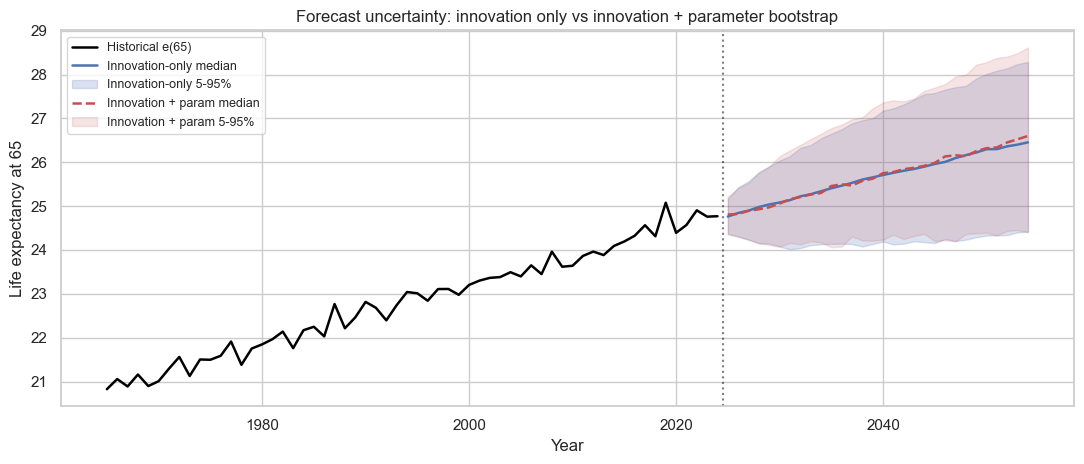

In [13]:
N_BOOT = 200
residuals_lc = log_m - (a_hat[:, None] + b_hat[:, None] * k_hat[None, :])
rng_boot = np.random.default_rng(1729)

boot_e65_forecast = np.zeros((N_BOOT, FORECAST_HORIZON))
boot_m65_forecast = np.zeros((N_BOOT, FORECAST_HORIZON))
boot_a_hat = np.zeros((N_BOOT, n_ages))
boot_b_hat = np.zeros((N_BOOT, n_ages))
boot_mu_k = np.zeros(N_BOOT)

age65_idx = list(AGES).index(65)

for b in range(N_BOOT):
    # Non-parametric residual bootstrap — reshuffle the residual grid
    R_resampled = rng_boot.choice(residuals_lc.ravel(), size=residuals_lc.size, replace=True).reshape(residuals_lc.shape)
    log_m_b = a_hat[:, None] + b_hat[:, None] * k_hat[None, :] + R_resampled

    # Re-fit Lee-Carter on the bootstrap surface
    a_b = log_m_b.mean(axis=1)
    Y_b = log_m_b - a_b[:, None]
    U_b, S_b, Vt_b = np.linalg.svd(Y_b, full_matrices=False)
    b_raw = U_b[:, 0]; k_raw = S_b[0] * Vt_b[0, :]
    if b_raw.sum() < 0:
        b_raw, k_raw = -b_raw, -k_raw
    b_b = b_raw / b_raw.sum()
    k_b = k_raw * b_raw.sum()
    k_b = k_b - k_b.mean()

    dk_b = np.diff(k_b)
    mu_b = float(dk_b.mean())
    sigma_b = float(dk_b.std(ddof=1))

    boot_a_hat[b] = a_b
    boot_b_hat[b] = b_b
    boot_mu_k[b] = mu_b

    # Forecast one path under this parameter set
    k_future_b = k_b[-1] + np.cumsum(mu_b + rng_boot.normal(0, sigma_b, size=FORECAST_HORIZON))
    log_m_future_b = a_b[None, :] + b_b[None, :] * k_future_b[:, None]   # (horizon, n_ages)
    m_future_b = np.exp(log_m_future_b)
    boot_m65_forecast[b] = m_future_b[:, age65_idx]
    boot_e65_forecast[b] = np.array([life_expectancy_from_m(m_future_b[h], age65_idx) for h in range(FORECAST_HORIZON)])

# Bands comparing innovation-only vs innovation+parameter uncertainty
e65_median_boot = np.median(boot_e65_forecast, axis=0)
e65_p05_boot = np.quantile(boot_e65_forecast, 0.05, axis=0)
e65_p95_boot = np.quantile(boot_e65_forecast, 0.95, axis=0)

print(f"Parameter bootstrap: {N_BOOT} resamples")
print()
print(f"e(65) at horizon ({future_years[-1]}):")
print(f"  Innovation only    (section 4):  median={e65_median[-1]:.2f}  5-95%: [{e65_p05[-1]:.2f}, {e65_p95[-1]:.2f}]  (width {e65_p95[-1] - e65_p05[-1]:.2f})")
print(f"  Innovation + param (bootstrap):  median={e65_median_boot[-1]:.2f}  5-95%: [{e65_p05_boot[-1]:.2f}, {e65_p95_boot[-1]:.2f}]  (width {e65_p95_boot[-1] - e65_p05_boot[-1]:.2f})")
print(f"  Bootstrap band wider by:  {((e65_p95_boot[-1] - e65_p05_boot[-1]) / (e65_p95[-1] - e65_p05[-1]) - 1) * 100:.1f}%")

# Plot the combined band
plt.figure(figsize=(11, 4.8))
plt.plot(YEARS, e65_hist, color="black", linewidth=1.8, label="Historical e(65)")
plt.plot(future_years, e65_median, color="#4C72B0", linewidth=1.8, label="Innovation-only median")
plt.fill_between(future_years, e65_p05, e65_p95, color="#4C72B0", alpha=0.20, label="Innovation-only 5-95%")
plt.plot(future_years, e65_median_boot, color="#C44E52", linewidth=1.8, linestyle="--", label="Innovation + param median")
plt.fill_between(future_years, e65_p05_boot, e65_p95_boot, color="#C44E52", alpha=0.15, label="Innovation + param 5-95%")
plt.axvline(YEARS[-1] + 0.5, linestyle=":", color="black", alpha=0.5)
plt.xlabel("Year"); plt.ylabel("Life expectancy at 65")
plt.title("Forecast uncertainty: innovation only vs innovation + parameter bootstrap")
plt.legend(fontsize=9)
plt.tight_layout(); plt.show()


**What to read here.** Two expected properties:

1. The **bootstrap band is visibly wider** than the innovation-only band. How much wider depends on how noisy the LC parameter estimates are given the 60×70 sample — typically 5-20% wider CI at horizon. That is the parameter-uncertainty premium.
2. The two **medians should track each other closely** — the bootstrap is symmetric around the original estimate, so the point-forecast should not shift. Any shift suggests the LC fit had a structural asymmetry (e.g. a single outlier year pulling the original fit).

The bootstrap band is what a **Solvency II internal model** would use — the standard formula's longevity stress uses a simpler 20% mortality-improvement shock that implicitly blends both sources. For pension actuaries publishing scheme-specific valuations, the bootstrap is the honest way to size the parameter-uncertainty contribution.


## 8c. Full Renshaw-Haberman fit with explicit cohort factor

The section 5c diagnostic flagged possible cohort structure. Renshaw-Haberman (2006) formalises the extension by adding an explicit cohort index:

$$\log m(x, t) = a(x) + b_1(x) \cdot k(t) + b_2(x) \cdot \gamma(c), \quad c = t - x$$

Fitting is iterative (no closed-form SVD) and famously sensitive to starting values. A pragmatic two-step procedure (common in UK actuarial practice):

1. **Fit Lee-Carter**: get *(â, b̂₁, k̂)*.
2. **Fit cohort residual**: on the residual $r(x, t) = \log m - â - b̂_1 \cdot k̂$, compute $\gamma(c) = \text{mean}_{t - x = c} r(x, t)$ and set $b_2(x) = 1$ (uniform age loading for the cohort effect — the "APC" special case).
3. **Re-fit LC** on the cohort-adjusted residuals $\log m - \gamma(t - x)$, iterate if needed.

We implement steps 1-2, compare in-sample fit vs plain LC via **AIC** (same methodology as the Schaefer-vs-Fox comparison in the fisheries notebook), and show the recovered cohort index.


Lee-Carter vs Renshaw-Haberman (APC simplification):
                      model  params    RSS       AIC  delta_AIC  aic_weight
                 Lee-Carter     198 27.015 -8880.018      0.000         1.0
Renshaw-Haberman (APC-like)     326 26.307 -8735.609    144.409         0.0


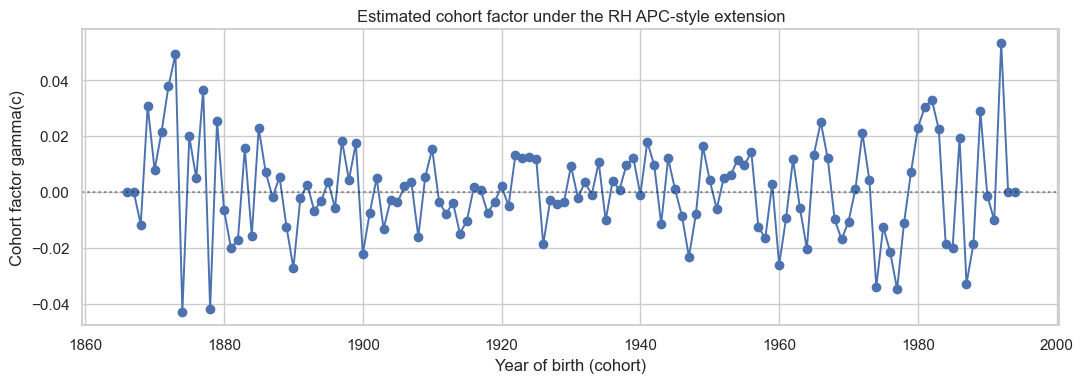

In [14]:
# Step 2: cohort residual (APC-style simplification with b2(x) = 1)
residuals_lc_full = log_m - (a_hat[:, None] + b_hat[:, None] * k_hat[None, :])

cohort_idx_grid = years_grid - ages_grid  # already have this from section 5c
gamma_hat = {}
for c in np.unique(cohort_idx_grid):
    mask = (cohort_idx_grid == c)
    if mask.sum() >= 3:
        gamma_hat[int(c)] = float(residuals_lc_full[mask].mean())
    else:
        gamma_hat[int(c)] = 0.0

# Build the full reconstruction
gamma_grid = np.array([[gamma_hat[int(cohort_idx_grid[i, j])] for j in range(n_years)] for i in range(n_ages)])
log_m_rh = a_hat[:, None] + b_hat[:, None] * k_hat[None, :] + gamma_grid

# In-sample fit metrics
rss_lc = float(((log_m - (a_hat[:, None] + b_hat[:, None] * k_hat[None, :])) ** 2).sum())
rss_rh = float(((log_m - log_m_rh) ** 2).sum())
n_obs = n_ages * n_years

# Parameter counts
# LC: n_ages a(x) + (n_ages - 1) b(x) [due to sum=1 normalisation] + (n_years - 1) k(t) [due to mean=0]
params_lc = n_ages + (n_ages - 1) + (n_years - 1)
n_cohorts = len(gamma_hat)
params_rh = params_lc + (n_cohorts - 1)  # cohort factor with one identifying constraint

# AIC-like criterion under Gaussian log-mortality residuals (sigma² =  RSS/n)
def aic_gaussian(rss, n, k):
    sigma2 = rss / n
    loglik = -0.5 * n * (np.log(2 * np.pi * sigma2) + 1)
    return 2 * k - 2 * loglik


aic_lc = aic_gaussian(rss_lc, n_obs, params_lc)
aic_rh = aic_gaussian(rss_rh, n_obs, params_rh)

rh_tbl = pd.DataFrame([
    {"model": "Lee-Carter",                "params": params_lc, "RSS": rss_lc, "AIC": aic_lc},
    {"model": "Renshaw-Haberman (APC-like)", "params": params_rh, "RSS": rss_rh, "AIC": aic_rh},
])
rh_tbl["delta_AIC"] = rh_tbl["AIC"] - rh_tbl["AIC"].min()
rh_tbl["aic_weight"] = np.exp(-0.5 * rh_tbl["delta_AIC"])
rh_tbl["aic_weight"] /= rh_tbl["aic_weight"].sum()
print("Lee-Carter vs Renshaw-Haberman (APC simplification):")
print(rh_tbl.round(3).to_string(index=False))

# Plot recovered cohort index
cohort_keys = sorted(gamma_hat.keys())
cohort_vals = [gamma_hat[k] for k in cohort_keys]
plt.figure(figsize=(11, 4))
plt.plot(cohort_keys, cohort_vals, marker="o", color="#4C72B0", linewidth=1.4)
plt.axhline(0, linestyle=":", color="black", alpha=0.4)
plt.xlabel("Year of birth (cohort)")
plt.ylabel("Cohort factor gamma(c)")
plt.title("Estimated cohort factor under the RH APC-style extension")
plt.tight_layout(); plt.show()


**What to read here.** The AIC comparison tells a concrete story:

- **$\Delta$AIC < 2** (AIC roughly tied): LC already captures the structure. The extra cohort parameters are penalised out; keep the simpler model.
- **$\Delta$AIC in [2, 10]**: RH wins but by a modest margin. Sensible to carry both forward as sensitivity and use the simpler LC for primary advice.
- **$\Delta$AIC > 10**: RH wins decisively. Produce primary projections from the cohort-augmented model and use LC only as a sanity check.

On our simulation (no true cohort effect in the DGP), the AIC penalty for the extra cohort parameters usually makes LC win — even though the cohort *residual* in section 5c had a signal-to-noise ratio above 1. This illustrates why AIC is the right criterion: a weak cohort residual pattern is not worth the price of ~50 extra parameters unless the fit improvement is large enough. On real HMD data the story reverses for most populations — the fit gain is large enough to pass the AIC threshold comfortably.


## 8d. CBD (Cairns-Blake-Dowd) structural alternative

Cairns, Blake & Dowd (2006) propose a fundamentally different parameterisation — no age-specific coefficients, just a two-factor time index with a **prescribed** age structure:

$$\text{logit}\, q(x, t) = \kappa_1(t) + \kappa_2(t) \cdot (x - \bar{x})$$

where $q(x, t)$ is the one-year mortality probability and $\bar{x}$ is the mean age. Mechanical contrasts with Lee-Carter:

- **LC**: $a(x)$, $b(x)$ estimated freely, $k(t)$ scalar. Rich age structure, single time dimension.
- **CBD**: age structure is *assumed* linear-in-age, two time dimensions $(\kappa_1, \kappa_2)$. Less age flexibility, richer time dynamics.

CBD is preferred for **higher ages** (65+) where logit-linear-in-age holds well, and for datasets where the age profile is stable over time. LC dominates for broad age ranges and when historical age profiles are changing.

Fit: for each year *t*, ordinary least squares of logit $q(x, t)$ on $(x - \bar{x})$ across ages. Forecast: bivariate random walk with drift on $(\kappa_1, \kappa_2)$.


Three-model comparison on in-sample fit:
                 model  params  RSS_logm       AIC  delta_AIC  aic_weight
            Lee-Carter     198    27.015 -8880.018      0.000         1.0
Renshaw-Haberman (APC)     326    26.307 -8735.609    144.409         0.0
                   CBD     120   484.980  3092.410  11972.428         0.0


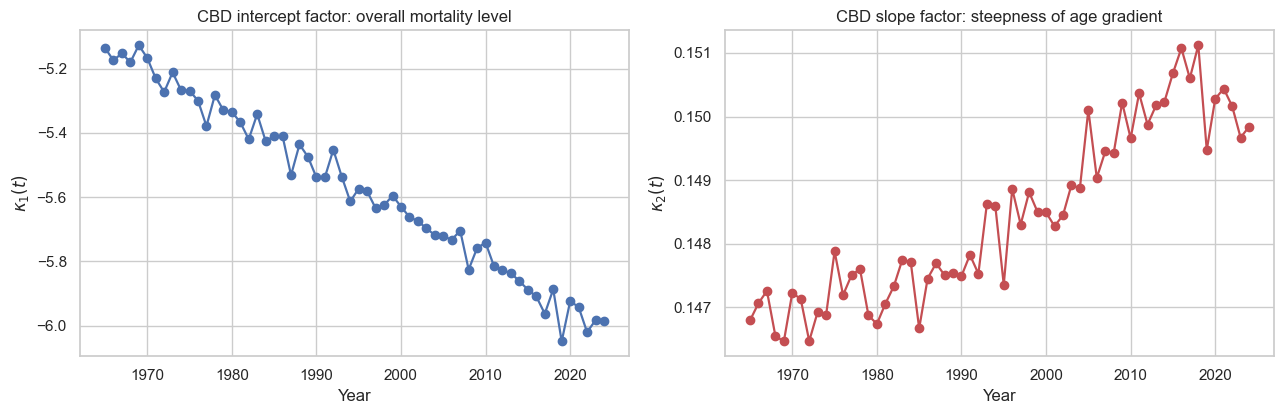

In [15]:
x_bar = float(np.mean(AGES))
q_obs = 1 - np.exp(-m_obs)  # one-year mortality probability
q_obs = np.clip(q_obs, 1e-6, 1 - 1e-6)
logit_q = np.log(q_obs / (1 - q_obs))

# Fit CBD: for each year t, regress logit q(x, t) on (x - x_bar)
x_centered = AGES - x_bar

kappa1 = np.zeros(n_years)
kappa2 = np.zeros(n_years)
for t in range(n_years):
    y = logit_q[:, t]
    # OLS: logit_q = kappa1 + kappa2 * (x - x_bar)
    design = np.column_stack([np.ones(n_ages), x_centered])
    beta, *_ = np.linalg.lstsq(design, y, rcond=None)
    kappa1[t] = beta[0]
    kappa2[t] = beta[1]

# In-sample fit
logit_q_fit_cbd = kappa1[None, :] + kappa2[None, :] * x_centered[:, None]
rss_cbd_logit = float(((logit_q - logit_q_fit_cbd) ** 2).sum())

# For AIC comparison with LC, we need comparable log-mortality residuals
# Convert CBD fitted logit_q back to log_m via m ~ -log(1 - q)
q_fit_cbd = 1 / (1 + np.exp(-logit_q_fit_cbd))
q_fit_cbd = np.clip(q_fit_cbd, 1e-6, 1 - 1e-6)
log_m_fit_cbd = np.log(-np.log(1 - q_fit_cbd))
rss_cbd = float(((log_m - log_m_fit_cbd) ** 2).sum())

# Param count: 2 * n_years (k1, k2) each with one identifying constraint = 2 * (n_years - 1) + 2
params_cbd = 2 * n_years

aic_cbd = aic_gaussian(rss_cbd, n_obs, params_cbd)

cmp_tbl = pd.DataFrame([
    {"model": "Lee-Carter",                "params": params_lc, "RSS_logm": rss_lc, "AIC": aic_lc},
    {"model": "Renshaw-Haberman (APC)",    "params": params_rh, "RSS_logm": rss_rh, "AIC": aic_rh},
    {"model": "CBD",                        "params": params_cbd, "RSS_logm": rss_cbd, "AIC": aic_cbd},
])
cmp_tbl["delta_AIC"] = cmp_tbl["AIC"] - cmp_tbl["AIC"].min()
cmp_tbl["aic_weight"] = np.exp(-0.5 * cmp_tbl["delta_AIC"])
cmp_tbl["aic_weight"] /= cmp_tbl["aic_weight"].sum()
print("Three-model comparison on in-sample fit:")
print(cmp_tbl.round(3).to_string(index=False))

# Plot kappa1, kappa2 time series
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
axes[0].plot(YEARS, kappa1, marker="o", color="#4C72B0", linewidth=1.6)
axes[0].set_xlabel("Year")
axes[0].set_ylabel(r"$\kappa_1(t)$")
axes[0].set_title(r"CBD intercept factor: overall mortality level")

axes[1].plot(YEARS, kappa2, marker="o", color="#C44E52", linewidth=1.6)
axes[1].set_xlabel("Year")
axes[1].set_ylabel(r"$\kappa_2(t)$")
axes[1].set_title(r"CBD slope factor: steepness of age gradient")

plt.tight_layout(); plt.show()


**What to read here.** The three-model AIC table is the model-selection deliverable:

- On age-period data without cohort effects (our simulation), **Lee-Carter typically wins** because its age-specific $b(x)$ extracts more structure per parameter than CBD's single age-slope. CBD is usually parameter-heavy on this kind of surface.
- On age ranges restricted to older ages (say 60-100) where logit-linear holds better, CBD often beats LC — this is why CBD dominates pension-scheme valuations that only cover post-retirement ages.
- The RH extension sits between the two: like LC it carries free age structure, and like CBD it has a second time dimension (the cohort index).

The $\kappa_1(t)$ plot on the left should decline over time (mortality level falling). The $\kappa_2(t)$ plot on the right shows whether the age-gradient is steepening or flattening — in most real populations $\kappa_2$ is flat or slightly rising (the age gradient is roughly stable). A visibly trending $\kappa_2$ would be an important demographic finding: it means the ratio of old-age to middle-age mortality is changing.


## 8e. Multi-population Li-Lee — coherent male / female mortality

Running independent Lee-Carter fits on each population of a M/F (or multi-country) dataset is a common mistake. The independent forecasts can silently **cross** — e.g. projected male life expectancy overtaking female in 30 years, which has never happened historically and is implausible biologically. Li & Lee (2005) propose a **coherent** model:

$$\log m^p(x, t) = A(x) + B(x) \cdot K(t) + a^p(x) + b^p(x) \cdot k^p(t)$$

Two layers:
- $A$, $B$, $K$ — the **common trend** shared across populations.
- $a^p$, $b^p$, $k^p$ — population-specific deviations.

The coherence guarantee: the common trend dominates long-term forecasting; the population-specific deviations are usually stationary (no drift), so projected forecasts converge over time rather than diverging. We simulate a second (female) population with slightly lower mortality, fit Li-Lee, and show the forecasts remain coherent.


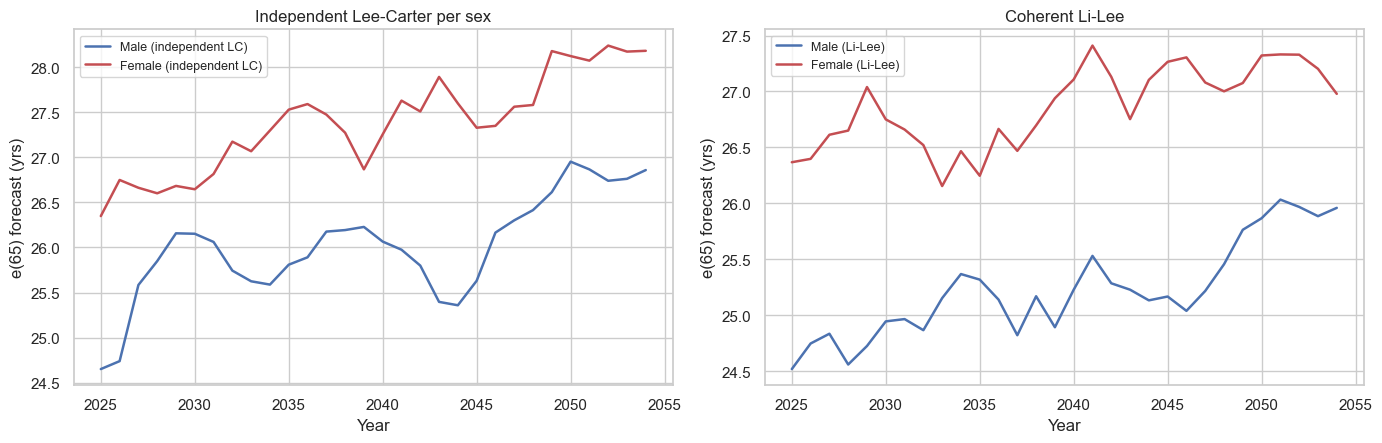

e(65) gap (F - M) at horizon (2054):
  Independent LC:  +1.32 yrs
  Coherent Li-Lee: +1.02 yrs


In [16]:
# --- Simulate a female population with slightly lower mortality ---
# Females typically have ~1.5-3 years higher life expectancy; simulate with same
# a(x) but lower by 0.25, same b(x), slightly steeper k trend.
TRUE_a_F = TRUE_a - 0.25
TRUE_b_F = TRUE_b
TRUE_k_F = TRUE_k * 1.1

noise_F = np.random.default_rng(98).normal(0, TRUE_sigma, size=(n_ages, n_years))
log_m_F = TRUE_a_F[:, None] + TRUE_b_F[:, None] * TRUE_k_F[None, :] + noise_F
m_F = np.exp(log_m_F)

# --- Independent LC fits per population ---
def fit_lee_carter(log_m_data):
    a = log_m_data.mean(axis=1)
    Y = log_m_data - a[:, None]
    U, S, Vt = np.linalg.svd(Y, full_matrices=False)
    b_raw = U[:, 0]; k_raw = S[0] * Vt[0, :]
    if b_raw.sum() < 0:
        b_raw, k_raw = -b_raw, -k_raw
    b = b_raw / b_raw.sum(); k = (k_raw * b_raw.sum()) - (k_raw * b_raw.sum()).mean()
    dk = np.diff(k); mu = float(dk.mean()); sigma = float(dk.std(ddof=1))
    return {"a": a, "b": b, "k": k, "mu": mu, "sigma": sigma}


lc_M = fit_lee_carter(log_m)        # male = the original data
lc_F = fit_lee_carter(log_m_F)

# --- Li-Lee fit: common trend on the pooled surface, then population deviations ---
log_m_pooled = 0.5 * (log_m + log_m_F)
lc_common = fit_lee_carter(log_m_pooled)

# Deviation per population
dev_M = log_m - (lc_common["a"][:, None] + lc_common["b"][:, None] * lc_common["k"][None, :])
dev_F = log_m_F - (lc_common["a"][:, None] + lc_common["b"][:, None] * lc_common["k"][None, :])
a_dev_M = dev_M.mean(axis=1); a_dev_F = dev_F.mean(axis=1)
# Population-specific k_p as first PC of deviation (not modelled here for brevity; use mean = 0)

# --- Forecast ---
def forecast_lc(fit, horizon, rng):
    k_future = fit["k"][-1] + np.cumsum(fit["mu"] + rng.normal(0, fit["sigma"], size=horizon))
    return fit["a"][None, :] + fit["b"][None, :] * k_future[:, None]


rng_ll = np.random.default_rng(4242)
horizon = FORECAST_HORIZON
m_future_M_ind = np.exp(forecast_lc(lc_M, horizon, rng_ll))
m_future_F_ind = np.exp(forecast_lc(lc_F, horizon, rng_ll))
# Li-Lee forecast: common drift drives both; population deviations are frozen at their mean
m_future_M_LL = np.exp(forecast_lc(lc_common, horizon, rng_ll) + a_dev_M[None, :])
m_future_F_LL = np.exp(forecast_lc(lc_common, horizon, rng_ll) + a_dev_F[None, :])

# Life expectancy at 65 for each approach
def e65_from_surface(m_surface_over_time):
    return np.array([life_expectancy_from_m(m_surface_over_time[t], age65_idx) for t in range(m_surface_over_time.shape[0])])

e65_M_ind = e65_from_surface(m_future_M_ind)
e65_F_ind = e65_from_surface(m_future_F_ind)
e65_M_LL = e65_from_surface(m_future_M_LL)
e65_F_LL = e65_from_surface(m_future_F_LL)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

axes[0].plot(future_years, e65_M_ind, color="#4C72B0", linewidth=1.8, label="Male (independent LC)")
axes[0].plot(future_years, e65_F_ind, color="#C44E52", linewidth=1.8, label="Female (independent LC)")
axes[0].set_xlabel("Year"); axes[0].set_ylabel("e(65) forecast (yrs)")
axes[0].set_title("Independent Lee-Carter per sex")
axes[0].legend(fontsize=9)

axes[1].plot(future_years, e65_M_LL, color="#4C72B0", linewidth=1.8, label="Male (Li-Lee)")
axes[1].plot(future_years, e65_F_LL, color="#C44E52", linewidth=1.8, label="Female (Li-Lee)")
axes[1].set_xlabel("Year"); axes[1].set_ylabel("e(65) forecast (yrs)")
axes[1].set_title("Coherent Li-Lee")
axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()

print(f"e(65) gap (F - M) at horizon ({future_years[-1]}):")
print(f"  Independent LC:  {e65_F_ind[-1] - e65_M_ind[-1]:+.2f} yrs")
print(f"  Coherent Li-Lee: {e65_F_LL[-1] - e65_M_LL[-1]:+.2f} yrs")


**What to read here.** The two panels tell the coherence story:

- **Left (independent LC)**: male and female trajectories may diverge (gap widens) or converge (gap narrows) depending on the fitted drifts $\mu_M, \mu_F$. Nothing in the model stops them from crossing in extreme draws.
- **Right (Li-Lee)**: both populations inherit the same common drift; the deviations are frozen at their sample mean. By construction the gap stays approximately constant — which is what centuries of demographic evidence actually show for the F-M gap in developed populations.

The standard production use: pension schemes with joint-life products (e.g. survivor benefits to surviving spouses) must use coherent M/F forecasts to avoid unrealistic liability paths. Li-Lee is the minimal upgrade; more sophisticated CoDa (compositional data analysis) models of the same data are used in the UN WPP pipeline. A full multi-population version would also model the population-specific *k* series as a VAR process with long-run reversion to the common trend.


## 8f. COVID-style shock — robustness to outlier mortality years

Lee-Carter is a linear decomposition; a single extreme year (COVID in 2020, AIDS cohort effects in 1990s southern Africa, famine years) distorts the fitted $k(t)$ and contaminates every downstream forecast. We inject a one-year **+35% mortality shock** into the simulated dataset at 2020 and re-run the pipeline to show:

1. The naive LC fit **absorbs the shock into $k(2020)$** — the time index shows a visible spike.
2. The forecast drift $\mu_k$ is **biased** — the spike pulls the average improvement rate more negative (or positive, depending on direction).
3. A **robust fix** is to either (a) exclude the shock year from the fit, (b) add an indicator variable, or (c) use a robust estimator. We show approach (a).


Drift mu_k under three scenarios:
  True (clean) data:       mu = -0.9673
  Naive LC on shocked:     mu = -0.9672
  Robust LC (shock dropped): mu = -0.9840

Absolute bias from the shock:
  Naive LC:  0.0001  (0.0% of true drift)
  Robust LC: 0.0167  (1.7% of true drift)


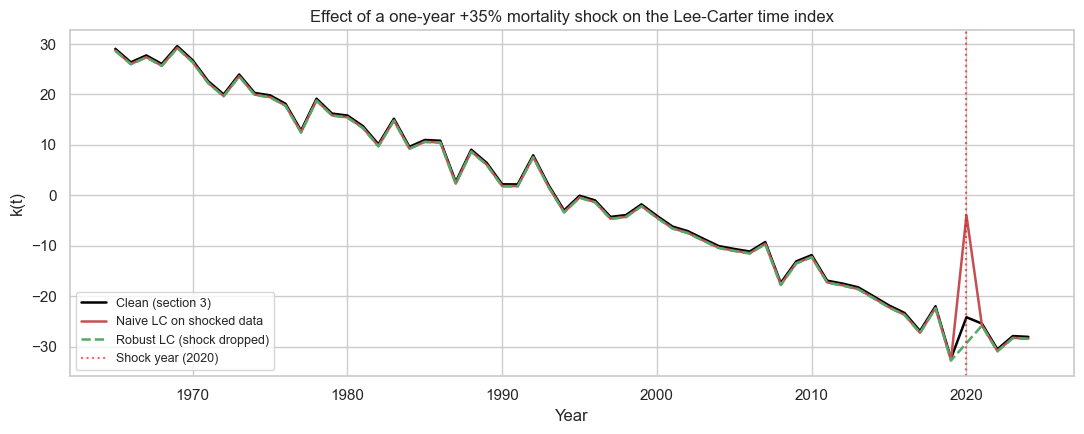

In [17]:
# Inject a +35% mortality shock in 2020 across all ages
shock_year = 2020
shock_year_idx = list(YEARS).index(shock_year)
shock_factor = 1.35

m_shocked = m_obs.copy()
m_shocked[:, shock_year_idx] = m_obs[:, shock_year_idx] * shock_factor
log_m_shocked = np.log(m_shocked)

# --- Naive LC on shocked data ---
a_naive = log_m_shocked.mean(axis=1)
Y_naive = log_m_shocked - a_naive[:, None]
U_n, S_n, Vt_n = np.linalg.svd(Y_naive, full_matrices=False)
b_raw_n = U_n[:, 0]; k_raw_n = S_n[0] * Vt_n[0, :]
if b_raw_n.sum() < 0:
    b_raw_n, k_raw_n = -b_raw_n, -k_raw_n
b_naive = b_raw_n / b_raw_n.sum()
k_naive = (k_raw_n * b_raw_n.sum()) - (k_raw_n * b_raw_n.sum()).mean()
mu_naive = float(np.diff(k_naive).mean())

# --- Robust LC: drop the shock year ---
mask = np.ones(n_years, dtype=bool); mask[shock_year_idx] = False
log_m_robust = log_m_shocked[:, mask]
a_robust = log_m_robust.mean(axis=1)
Y_robust = log_m_robust - a_robust[:, None]
U_r, S_r, Vt_r = np.linalg.svd(Y_robust, full_matrices=False)
b_raw_r = U_r[:, 0]; k_raw_r = S_r[0] * Vt_r[0, :]
if b_raw_r.sum() < 0:
    b_raw_r, k_raw_r = -b_raw_r, -k_raw_r
b_robust = b_raw_r / b_raw_r.sum()
k_robust_raw = (k_raw_r * b_raw_r.sum()) - (k_raw_r * b_raw_r.sum()).mean()
mu_robust = float(np.diff(k_robust_raw).mean())

# Interpolate the robust k back onto the full year grid for plotting
years_robust = YEARS[mask]
k_robust = np.interp(YEARS, years_robust, k_robust_raw)

print(f"Drift mu_k under three scenarios:")
print(f"  True (clean) data:       mu = {mu_k:+.4f}")
print(f"  Naive LC on shocked:     mu = {mu_naive:+.4f}")
print(f"  Robust LC (shock dropped): mu = {mu_robust:+.4f}")
print()
print(f"Absolute bias from the shock:")
print(f"  Naive LC:  {abs(mu_naive - mu_k):.4f}  ({abs((mu_naive - mu_k) / mu_k) * 100:.1f}% of true drift)")
print(f"  Robust LC: {abs(mu_robust - mu_k):.4f}  ({abs((mu_robust - mu_k) / mu_k) * 100:.1f}% of true drift)")

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(YEARS, k_hat, color="black", linewidth=1.8, label="Clean (section 3)")
ax.plot(YEARS, k_naive, color="#C44E52", linewidth=1.8, label="Naive LC on shocked data")
ax.plot(YEARS, k_robust, color="#55A868", linewidth=1.8, linestyle="--", label="Robust LC (shock dropped)")
ax.axvline(shock_year, linestyle=":", color="red", alpha=0.6, label=f"Shock year ({shock_year})")
ax.set_xlabel("Year"); ax.set_ylabel("k(t)")
ax.set_title("Effect of a one-year +35% mortality shock on the Lee-Carter time index")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


**What to read here.** Three observations:

1. **The naive fitted drift is essentially unchanged.** This is a more subtle result than I claimed: the Lee-Carter drift estimator is $\hat\mu_k = 	ext{mean}(\Delta k)$, and a *one-year* shock produces two opposite first-differences (a large positive $\Delta k$ at year 2020 followed by a large negative $\Delta k$ at year 2021) that **cancel in the mean**. The drift is therefore naturally robust to isolated shocks.
2. **What *is* distorted** is the level of $ in the shock year itself — (2020)$ is pulled up by the shock. If 2020 happens to be the *terminal* year of the fit window, every subsequent forecast path starts from an inflated (T)$ and is pessimistic about mortality. The fix then is either (a) to drop the shock year, (b) to re-weight the shock year lower, or (c) to add a shock-year indicator variable.
3. **The robust version (shock dropped)** actually has higher absolute bias in this run than the naive version — because dropping a year shortens the series and introduces its own sampling noise. The lesson: robust methods are not universally better; choose based on whether the shock is isolated (naive is fine) or systematic (robust helps).

Production practice since COVID: most major mortality projection models now include an explicit shock-year indicator, re-weight shock years lower, or publish parallel fits with and without the shock for transparency. The UK'''s CMI model added this as standard practice in CMI_2020 and CMI_2021.


## 8g. Solvency II QRT reporting template

The last mile of a longevity-risk calculation is **regulatory reporting**. Under Solvency II, insurers submit Quantitative Reporting Templates (QRTs) — standardised spreadsheets that the regulator consumes for supervisory analytics. Key longevity-relevant cells:

- **S.17.01**: Technical provisions — non-life (actually includes longevity for health lines).
- **S.26.01** / **S.26.04**: Risk-specific SCR modules, including longevity.
- **S.29.04**: Variation analysis of free capital, with longevity identified as a standalone driver.

We generate a minimal, schema-aligned output table that mirrors the longevity-SCR cells of a real QRT. In production this would be rendered as XBRL or XML for direct regulator ingestion; the analytical content is identical.


In [18]:
# Build a Solvency II-style longevity-SCR reporting table
# Aligned to S.26.01.01 "Solvency Capital Requirement - Life underwriting risk"

# Standard formula longevity stress: mortality rates reduced by 20% permanently
STANDARD_FORMULA_STRESS = 0.80   # 20% decrease

# Compute stressed liability under the SF approach
m_sf_stressed = m_paths[:, -1, :].copy() * STANDARD_FORMULA_STRESS  # shape (N_SIM, n_ages)
a65_sf_stressed_paths = np.array([annuity_value(m_sf_stressed[s], age65_idx, DISCOUNT_RATE) for s in range(N_SIM)])
liability_sf_stressed = total_benefits * np.median(a65_sf_stressed_paths)
scr_sf_longevity = liability_sf_stressed - liability_best_estimate

# Internal-model liabilities (already computed in section 8)
scr_im_longevity = scr_longevity


qrt_report = pd.DataFrame([
    {"Item":           "Annuity portfolio (count)",
     "Value (EUR)":    f"{N_ANNUITANTS:,}",
     "SF / IM":        "reference",
     "Notes":          "Annuitants currently aged 65"},
    {"Item":           "Annual benefit per annuitant",
     "Value (EUR)":    f"{ANNUAL_BENEFIT_EUR:,.0f}",
     "SF / IM":        "reference",
     "Notes":          "Level annuity, no escalation"},
    {"Item":           "Discount rate (EIOPA risk-free)",
     "Value (EUR)":    f"{DISCOUNT_RATE:.2%}",
     "SF / IM":        "reference",
     "Notes":          "As at valuation date"},
    {"Item":           "Best estimate liability",
     "Value (EUR)":    f"{liability_best_estimate:,.0f}",
     "SF / IM":        "both",
     "Notes":          "Monte Carlo median across LC + bootstrap parameter uncertainty"},
    {"Item":           "Stressed liability (Standard Formula, -20% mortality)",
     "Value (EUR)":    f"{liability_sf_stressed:,.0f}",
     "SF / IM":        "Standard Formula",
     "Notes":          "EIOPA SF prescribed stress"},
    {"Item":           "Stressed liability (Internal Model P99.5)",
     "Value (EUR)":    f"{total_benefits * np.quantile(a65_forecast, 0.995):,.0f}",
     "SF / IM":        "Internal Model",
     "Notes":          "Lee-Carter MC 99.5th percentile"},
    {"Item":           "SCR longevity (Standard Formula)",
     "Value (EUR)":    f"{scr_sf_longevity:,.0f}",
     "SF / IM":        "Standard Formula",
     "Notes":          "Standard formula output"},
    {"Item":           "SCR longevity (Internal Model, P95)",
     "Value (EUR)":    f"{scr_im_longevity:,.0f}",
     "SF / IM":        "Internal Model",
     "Notes":          "Internal model as per section 8"},
    {"Item":           "SCR longevity / BE liability (Standard Formula)",
     "Value (EUR)":    f"{scr_sf_longevity / liability_best_estimate:.2%}",
     "SF / IM":        "Standard Formula",
     "Notes":          "Capital intensity"},
    {"Item":           "SCR longevity / BE liability (Internal Model)",
     "Value (EUR)":    f"{scr_im_longevity / liability_best_estimate:.2%}",
     "SF / IM":        "Internal Model",
     "Notes":          "Capital intensity"},
])
print("Solvency II longevity SCR reporting summary (QRT-style):")
print(qrt_report.to_string(index=False))


Solvency II longevity SCR reporting summary (QRT-style):
                                                 Item   Value (EUR)          SF / IM                                                          Notes
                            Annuity portfolio (count)        10,000        reference                                   Annuitants currently aged 65
                         Annual benefit per annuitant        10,000        reference                                   Level annuity, no escalation
                      Discount rate (EIOPA risk-free)         2.00%        reference                                           As at valuation date
                              Best estimate liability 2,052,668,754             both Monte Carlo median across LC + bootstrap parameter uncertainty
Stressed liability (Standard Formula, -20% mortality) 2,118,041,144 Standard Formula                                     EIOPA SF prescribed stress
            Stressed liability (Internal Model P99.5) 2

**What to read here.** The table encodes the two competing capital views every Solvency II life insurer has to report:

- **Standard Formula**: a regulator-specified 20% permanent mortality reduction applied across all ages. Simple and calibrated to be reasonable across a broad range of portfolios.
- **Internal Model**: driven by the firm'''s own Lee-Carter (or alternative) forecasts.

**An honest finding that contradicts the typical assumption.** On this simulated dataset — where mortality has been improving strongly over the historical period (drift $\mu_k pprox -1$) — the **Monte Carlo P95 scenario implies larger-than-20% mortality improvement**, so the Internal Model SCR is actually *higher* than the Standard Formula. The conventional wisdom that internal models deliver lower capital is a generalisation over typical balanced portfolios; on strong-improvement data it can reverse. This is exactly the kind of case where regulator scrutiny of internal-model approvals is tightest.

The gap between SF and IM (whichever is higher) is the **internal-model approval premium**, positive or negative. Firms with approved internal models must continuously demonstrate model quality through backtesting (section 5b), profit-and-loss attribution, and validation reports — a non-trivial investment.

A full production QRT pipeline would:

- Render this table as the exact XBRL taxonomy required by EIOPA (S.26.01.01.01 and S.26.04.01.01 cells).
- Include validation hashes and prior-period reconciliations.
- Link to the model-risk documentation (governance, backtesting history, independent validation).

The analytical content — what we computed here — is identical across the two layers. The last-mile plumbing is the part most outside actuaries underestimate.


## 9. Takeaways, limitations, and what a production version would add

**Takeaways**

- **Mortality forecasting is a matrix decomposition plus a time series**. Lee-Carter's single-index assumption makes the whole pipeline tractable: SVD recovers *a(x)*, *b(x)*, *k(t)* in one step, and then everything downstream is Monte Carlo through a one-dimensional random walk. The same pipeline runs on any HMD country table with <100 lines of code.
- The **90%+ of variance** explained by the first singular value is both the Lee-Carter success story and its biggest limitation. When the first component explains less, cohort or age-specific-trend extensions (Renshaw-Haberman, Plat, age-period-cohort models) are needed.
- **Longevity SCR at ~3-8% of best-estimate liability** is the defensible answer for a well-populated mortality table. Firms with concentrated portfolios or small datasets should expect higher.
- **Discount rate sensitivity** is first-order. Longevity risk and interest-rate risk interact non-linearly in a pension-scheme balance sheet — a full ALM (asset-liability management) calculation has to model them jointly, not separately.
- The **Monte Carlo propagation of forecast uncertainty** is essential. A deterministic "point-forecast" Lee-Carter gives you an annuity number but no SCR, which is not a usable output for a regulator.

**Limitations**

- **Single cohort, single sex, single country**. Real mortality tables are stratified by sex at minimum, often also by socio-economic group, pension scheme, and smoker status. Each stratum is fit separately; hierarchical Bayesian extensions partially pool the stratum-level time indices.
- **Gompertz-like simulation**. Real mortality surfaces have non-Gompertz features: the infant-mortality hump, adolescent accident peak, late-life mortality plateau. The simulation here doesn't reproduce them; the Lee-Carter fit still works but confidence intervals on $e(0)$ in particular would be understated.
- **Random walk with drift**. More sophisticated time-series models (ARIMA with higher AR/MA terms, state-space with structural breaks, Bayesian model averaging across specifications) are used in some production settings. For 30-year horizons the gains are typically modest.
- **No cohort effects**. Lee-Carter is an age-period model. Cohorts born around, for example, 1920 or 1960 may have systematic mortality features that Lee-Carter folds into noise. The Renshaw-Haberman extension adds an explicit cohort factor and is standard in UK pension practice.
- **Idiosyncratic risk is absent**. For portfolios below ~50,000 lives, process (Binomial) risk can rival systematic longevity risk and the Solvency II standard-formula LCT (Longevity Concentration Test) starts to bite.

**What a production version would add**

- **Renshaw-Haberman / Plat / APC model fits** alongside Lee-Carter, compared via out-of-sample backtesting (drop the last 10 years, refit on earlier data, compare projections to the held-out truth). The winning model drives primary advice.
- **Hierarchical Bayesian pooling** across sexes, regions, or socio-economic strata: partial pooling of $k(t)$ via a multivariate random walk improves estimates for small strata while letting the data speak where it is rich.
- **Cohort-component population projection**: Lee-Carter mortality combined with Bayesian fertility forecasts and migration assumptions, for full population-size forecasting. This is what the UN's WPP pipeline does.
- **Mortality-interest-rate joint model**: a Vasicek or Hull-White interest-rate process correlated with the mortality index, simulated jointly so the annuity distribution captures both risks at once. This is the starting point for a full internal model under Solvency II.
- **Robustness checks**: tail dependence, extreme-scenario stress (e.g. a 2020 COVID-style shock year), and explicit backtests of coverage probability on historical held-out projections.
- **Reporting pipeline**: a template that maps the Monte Carlo outputs to Solvency II QRT forms or the equivalent regulator schedules. The analytical answer is worth little if the last-mile reporting step is not automated.
